> **Superseded.** This notebook's EDA, dataset build, model training, and model analysis code has been split into scripts/gb_common.py, scripts/build_train_pool.py, scripts/experiments.py, scripts/gb_train.py, eda_dataset.ipynb, and model_analysis.ipynb. Kept here for reference against the original logic, not maintained going forward.


#### Gradient boosting analysis on the alphaearth_wetland_joined data.

In [1]:
import duckdb
import pandas as pd

pd.set_option("display.max_columns", None)

preview = duckdb.sql("""
    SELECT *
    FROM read_parquet('data/processed/alphaearth_wetland_joined/*.parquet')
    LIMIT 5
""").df()
print(preview.columns.tolist())
preview

['row', 'col', 'x', 'y', 'dist_to_developed_2019_m', 'label', 'label_name', 'tile_row', 'tile_col', 'tile_id', 'A00_2017', 'A01_2017', 'A02_2017', 'A03_2017', 'A04_2017', 'A05_2017', 'A06_2017', 'A07_2017', 'A08_2017', 'A09_2017', 'A10_2017', 'A11_2017', 'A12_2017', 'A13_2017', 'A14_2017', 'A15_2017', 'A16_2017', 'A17_2017', 'A18_2017', 'A19_2017', 'A20_2017', 'A21_2017', 'A22_2017', 'A23_2017', 'A24_2017', 'A25_2017', 'A26_2017', 'A27_2017', 'A28_2017', 'A29_2017', 'A30_2017', 'A31_2017', 'A32_2017', 'A33_2017', 'A34_2017', 'A35_2017', 'A36_2017', 'A37_2017', 'A38_2017', 'A39_2017', 'A40_2017', 'A41_2017', 'A42_2017', 'A43_2017', 'A44_2017', 'A45_2017', 'A46_2017', 'A47_2017', 'A48_2017', 'A49_2017', 'A50_2017', 'A51_2017', 'A52_2017', 'A53_2017', 'A54_2017', 'A55_2017', 'A56_2017', 'A57_2017', 'A58_2017', 'A59_2017', 'A60_2017', 'A61_2017', 'A62_2017', 'A63_2017', 'A00_2018', 'A01_2018', 'A02_2018', 'A03_2018', 'A04_2018', 'A05_2018', 'A06_2018', 'A07_2018', 'A08_2018', 'A09_2018', '

,row,col,x,y,dist_to_developed_2019_m,label,label_name,tile_row,tile_col,tile_id,A00_2017,A01_2017,A02_2017,A03_2017,A04_2017,A05_2017,A06_2017,A07_2017,A08_2017,A09_2017,A10_2017,A11_2017,A12_2017,A13_2017,A14_2017,A15_2017,A16_2017,A17_2017,A18_2017,A19_2017,A20_2017,A21_2017,A22_2017,A23_2017,A24_2017,A25_2017,A26_2017,A27_2017,A28_2017,A29_2017,A30_2017,A31_2017,A32_2017,A33_2017,A34_2017,A35_2017,A36_2017,A37_2017,A38_2017,A39_2017,A40_2017,A41_2017,A42_2017,A43_2017,A44_2017,A45_2017,A46_2017,A47_2017,A48_2017,A49_2017,A50_2017,A51_2017,A52_2017,A53_2017,A54_2017,A55_2017,A56_2017,A57_2017,A58_2017,A59_2017,A60_2017,A61_2017,A62_2017,A63_2017,A00_2018,A01_2018,A02_2018,A03_2018,A04_2018,A05_2018,A06_2018,A07_2018,A08_2018,A09_2018,A10_2018,A11_2018,A12_2018,A13_2018,A14_2018,A15_2018,A16_2018,A17_2018,A18_2018,A19_2018,A20_2018,A21_2018,A22_2018,A23_2018,A24_2018,A25_2018,A26_2018,A27_2018,A28_2018,A29_2018,A30_2018,A31_2018,A32_2018,A33_2018,A34_2018,A35_2018,A36_2018,A37_2018,A38_2018,A39_2018,A40_2018,A41_2018,A42_2018,A43_2018,A44_2018,A45_2018,A46_2018,A47_2018,A48_2018,A49_2018,A50_2018,A51_2018,A52_2018,A53_2018,A54_2018,A55_2018,A56_2018,A57_2018,A58_2018,A59_2018,A60_2018,A61_2018,A62_2018,A63_2018,A00_2019,A01_2019,A02_2019,A03_2019,A04_2019,A05_2019,A06_2019,A07_2019,A08_2019,A09_2019,A10_2019,A11_2019,A12_2019,A13_2019,A14_2019,A15_2019,A16_2019,A17_2019,A18_2019,A19_2019,A20_2019,A21_2019,A22_2019,A23_2019,A24_2019,A25_2019,A26_2019,A27_2019,A28_2019,A29_2019,A30_2019,A31_2019,A32_2019,A33_2019,A34_2019,A35_2019,A36_2019,A37_2019,A38_2019,A39_2019,A40_2019,A41_2019,A42_2019,A43_2019,A44_2019,A45_2019,A46_2019,A47_2019,A48_2019,A49_2019,A50_2019,A51_2019,A52_2019,A53_2019,A54_2019,A55_2019,A56_2019,A57_2019,A58_2019,A59_2019,A60_2019,A61_2019,A62_2019,A63_2019,block_id
0,1944,1392,823530.0,917820.0,429.534637,0,Remained wetland,1899,1970,r039_c053,0.086614,-0.007874,-0.086614,0.133858,-0.173228,-0.228346,0.047244,0.173228,-0.055118,0.070866,-0.062992,0.007874,-0.204724,0.078740,-0.007874,-0.047244,-0.204724,-0.015748,0.102362,-0.070866,-0.188976,0.055118,-0.055118,-0.062992,0.062992,0.165354,-0.165354,0.023622,0.007874,0.228346,0.110236,0.070866,-0.031496,-0.039370,-0.157480,0.023622,-0.078740,-0.157480,0.094488,-0.173228,-0.157480,0.062992,0.102362,0.047244,0.094488,-0.031496,0.000000,-0.141732,0.401575,-0.125984,-0.204724,-0.196850,-0.047244,0.102362,0.039370,0.007874,-0.031496,0.110236,0.023622,-0.165354,-0.102362,-0.173228,0.070866,0.078740,0.055118,0.000000,-0.133858,0.118110,-0.165354,-0.251969,0.047244,0.133858,-0.086614,0.023622,-0.110236,0.023622,-0.204724,0.078740,-0.015748,-0.070866,-0.165354,-0.062992,0.086614,-0.078740,-0.173228,0.047244,-0.094488,-0.007874,0.039370,0.173228,-0.133858,0.015748,0.023622,0.228346,0.094488,0.023622,-0.023622,-0.070866,-0.133858,-0.023622,-0.078740,-0.118110,0.102362,-0.141732,-0.165354,0.102362,0.118110,0.023622,0.125984,0.007874,-0.015748,-0.149606,0.433071,-0.149606,-0.228346,-0.173228,-0.031496,0.086614,0.078740,0.070866,-0.047244,0.118110,0.039370,-0.157480,-0.078740,-0.157480,0.070866,0.078740,-0.023622,-0.062992,-0.149606,0.188976,-0.149606,-0.212598,0.031496,0.023622,-0.102362,-0.007874,-0.062992,0.015748,-0.204724,0.055118,-0.094488,-0.070866,-0.181102,0.023622,0.031496,-0.039370,-0.078740,0.055118,-0.007874,-0.023622,0.000000,0.157480,-0.055118,0.000000,0.031496,0.196850,0.141732,-0.015748,-0.007874,-0.007874,-0.267717,-0.015748,-0.078740,-0.070866,0.149606,-0.220472,-0.125984,0.070866,0.094488,0.039370,0.165354,0.031496,0.039370,-0.157480,0.338583,-0.133858,-0.220472,-0.094488,-0.007874,0.149606,0.173228,0.070866,-0.086614,0.133858,0.141732,-0.212598,0.015748,-0.188976,0.110236,0.047244,b0239_0323
1,1944,1393,823560.0,917820.0,400.249908,0,Remained wetland,1899,1971,r039_c053,0.078740,0.007874,-0.094488,0.133858,-0.165354,-0.228346,0.039370,0.188976,-0.055118,0.078740,-0.047244,0.007874,-0.212598,0.078740,0.000000,-0.047244,-0.196850,-0.015748,0.102362,-0.

## EDA

Check the joined AlphaEarth and NLCD samples before touching the model: label
balance, embedding value ranges, whether the granule seam problem seen on some
coastal tiles during the AlphaEarth export shows up here, where samples fall
geographically, and whether `dist_to_developed_2019_m` behaves the way the
labeling scheme implies. Queries run against the parquet directory in place with
DuckDB instead of loading all 59M rows into pandas. The joined tiles are 9GB on
disk, about 46GB as a dense float32 frame, well past what fits in memory here.

In [2]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

JOINED_GLOB = "data/processed/alphaearth_wetland_joined/*.parquet"

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW samples AS SELECT * FROM read_parquet('{JOINED_GLOB}')")
con.execute("SELECT COUNT(*) AS n_rows, COUNT(DISTINCT tile_id) AS n_tiles FROM samples").df()

,n_rows,n_tiles
0,59267331,76


### Label balance

This number decides how we split and weight for training. Expect "Remained
wetland" to dominate heavily, since conversion is a rare event over a 5 year
window.

In [3]:
label_counts = con.execute("""
    SELECT label, label_name, COUNT(*) AS n
    FROM samples
    GROUP BY label, label_name
    ORDER BY label
""").df()
label_counts["frac"] = label_counts["n"] / label_counts["n"].sum()
label_counts

,label,label_name,n,frac
0,0,Remained wetland,58878170,0.993434
1,1,Converted to developed,165908,0.002799
2,2,Converted to other (non-developed),223253,0.003767


### Embedding value range

`export_alphaearth_30m.py` decodes the raw uint8 bands back to `[-1, 1]` using
`OFFSET` and `SCALE_FACTOR`. If the decode or the join went wrong somewhere,
this is the first place it would show: either the range is off, or a NODATA
fill leaked through (the assemble step is supposed to drop those, not leave
them in).

In [4]:
band_cols = [f"A{b:02d}_{year}" for year in (2017, 2018, 2019) for b in range(64)]

band_bounds = con.execute(f"""
    SELECT MIN(v) AS min_val, MAX(v) AS max_val, COUNT(*) AS n_vals
    FROM samples
    UNPIVOT (v FOR band IN ({", ".join(band_cols)}))
""").df()
band_bounds

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_val,max_val,n_vals
0,-0.582677,0.535433,11379327552


### Coastal tile screen

The AlphaEarth export run turned up nondeterminism in the seams between
granules on some coastal tiles. This is a coarse check for whether that shows
up here before we trust the pooled data. Row counts per tile catch a tile
that's missing chunks of coverage. Stats per tile on a single band (A00_2019,
an arbitrary choice) catch a tile whose embedding distribution is obviously
off from its neighbors. This is a screen, not a diagnosis: anything that
stands out here is worth checking against the raw tif before deciding
whether to drop or reprocess that tile.

In [5]:
tile_stats = con.execute("""
    SELECT tile_id,
           COUNT(*) AS n,
           AVG(A00_2019) AS a00_mean,
           STDDEV(A00_2019) AS a00_std,
           MIN(A00_2019) AS a00_min,
           MAX(A00_2019) AS a00_max
    FROM samples
    GROUP BY tile_id
    ORDER BY tile_id
""").df()

# flag tiles whose A00_2019 mean sits far from the mean across tiles: a cheap
# proxy for "this tile's embeddings look systematically different"
overall_mean, overall_std = tile_stats["a00_mean"].mean(), tile_stats["a00_mean"].std()
tile_stats["z"] = (tile_stats["a00_mean"] - overall_mean) / overall_std
tile_stats.reindex(tile_stats["z"].abs().sort_values(ascending=False).index).head(10)

,tile_id,n,a00_mean,a00_std,a00_min,a00_max,z
56,r045_c065,998933,-0.020827,0.078285,-0.283465,0.228346,-2.571493
4,r039_c057,267288,-0.012198,0.065106,-0.283465,0.212598,-2.286117
61,r046_c065,685714,-0.009006,0.070333,-0.259843,0.220472,-2.180544
27,r041_c058,1738110,0.114774,0.058594,-0.259843,0.259843,1.913131
55,r045_c064,1101011,0.003133,0.067856,-0.259843,0.259843,-1.779089
71,r049_c066,373402,0.109925,0.042821,-0.078740,0.236220,1.752770
70,r049_c065,603734,0.109789,0.039290,-0.102362,0.236220,1.748273
3,r039_c056,318066,0.007171,0.066567,-0.275591,0.236220,-1.645534
8,r039_c061,383149,0.105062,0.053716,-0.165354,0.251969,1.591929
36,r042_c060,137280,0.101054,0.049594,-0.118110,0.275591,1.459391


### Spatial distribution

Pull a random sample (small enough to plot, not meant to be representative of
class balance) and check that coverage looks like Florida's wetlands, and that
converted pixels aren't clustered somewhere that smells like a processing
artifact rather than real land cover change.

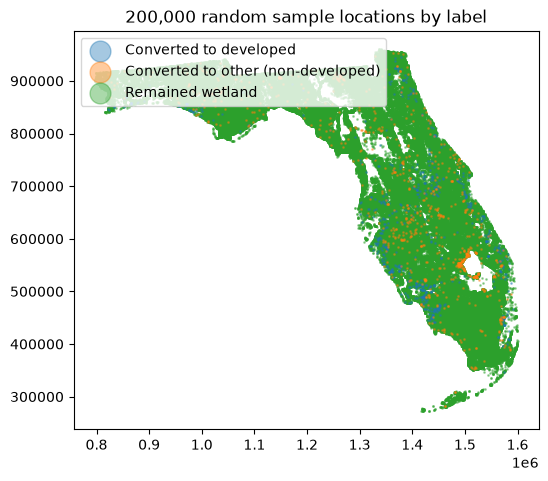

In [6]:
spatial_sample = con.execute("""
    SELECT x, y, label_name
    FROM samples
    USING SAMPLE 200000 ROWS
""").df()

fig, ax = plt.subplots(figsize=(6, 8))
for name, grp in spatial_sample.groupby("label_name"):
    # converted classes plotted last / on top so they aren't buried under the
    # much larger "remained wetland" cloud
    z = 2 if name == "Remained wetland" else 3
    ax.scatter(grp["x"], grp["y"], s=1, alpha=0.4, label=name, zorder=z)
ax.set_aspect("equal")
ax.set_title(f"{len(spatial_sample):,} random sample locations by label")
ax.legend(markerscale=15, loc="upper left")

### `dist_to_developed_2019_m` versus label

Distance to the nearest 2019 developed pixel is one of the strongest priors
for conversion risk: proximity to existing development. Pixels that converted
between 2019 and 2024 should sit closer to 2019 development on average than
pixels that stayed wetland. If they don't, that's worth understanding before
we treat this column as a trustworthy feature.

In [7]:
dist_by_label = con.execute("""
    SELECT label_name,
           COUNT(*) AS n,
           AVG(dist_to_developed_2019_m) AS mean_dist_m,
           MEDIAN(dist_to_developed_2019_m) AS median_dist_m
    FROM samples
    GROUP BY label_name
    ORDER BY mean_dist_m
""").df()
dist_by_label

,label_name,n,mean_dist_m,median_dist_m
0,Converted to developed,165908,88.230664,42.426407
1,Converted to other (non-developed),223253,1101.231279,424.264069
2,Remained wetland,58878170,1605.006973,510.000000


In [8]:
import matplotlib.ticker as mticker

# label=0 outnumbers label=1 by about 350 to 1, so one shared linear axis would
# flatten the conversion classes to nothing, plot each one on its own axis below.
# also bin the distance itself in log space since it spans 30m (one AlphaEarth
# pixel) to over 100km and is heavily right skewed
LABEL_COLORS = {
    "Remained wetland": "#2a78d6",
    "Converted to other (non-developed)": "#1baf7a",
    "Converted to developed": "#eb6834",
}
LOG_BIN_WIDTH = 0.05  # 20 bins per decade
DIST_TICKS = [30, 100, 300, 1000, 3000, 10000, 30000, 100000]

dist_hist = con.execute(f"""
    SELECT label_name,
           FLOOR(LOG10(dist_to_developed_2019_m) / {LOG_BIN_WIDTH}) AS bin_idx,
           COUNT(*) AS n
    FROM samples
    GROUP BY label_name, bin_idx
""").df()
dist_hist["left_m"] = 10 ** (dist_hist["bin_idx"] * LOG_BIN_WIDTH)
dist_hist["right_m"] = 10 ** ((dist_hist["bin_idx"] + 1) * LOG_BIN_WIDTH)


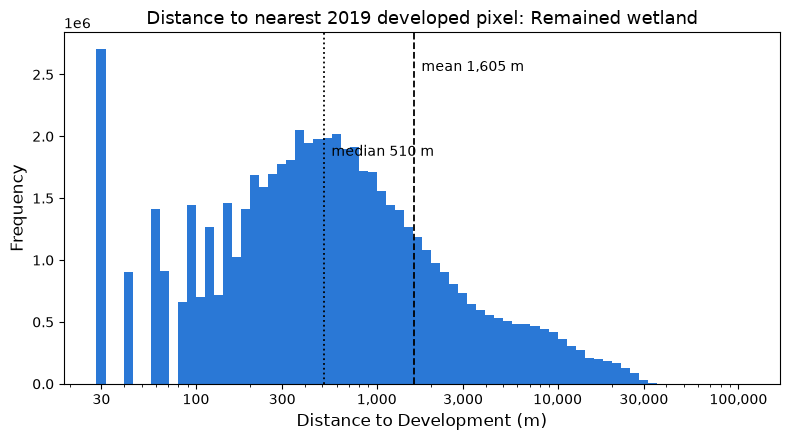

In [9]:
label_name = "Remained wetland"
grp = dist_hist[dist_hist["label_name"] == label_name].sort_values("left_m")
stats = dist_by_label.set_index("label_name").loc[label_name]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=LABEL_COLORS[label_name], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(f"Distance to nearest 2019 developed pixel: Remained wetland", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(stats["mean_dist_m"], color="black", linestyle="--", linewidth=1.3)
ax.axvline(stats["median_dist_m"], color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(stats["mean_dist_m"] * 1.1, ymax * 0.92, f"mean {stats['mean_dist_m']:,.0f} m", va="top", fontsize=10)
ax.text(stats["median_dist_m"] * 1.1, ymax * 0.68, f"median {stats['median_dist_m']:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


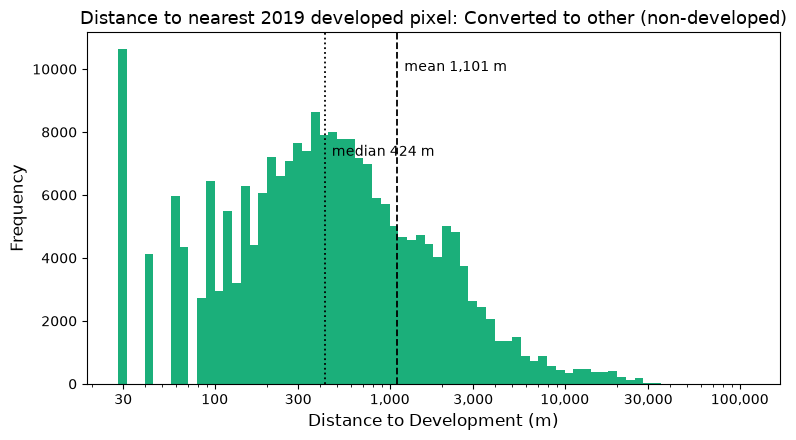

In [10]:
label_name = "Converted to other (non-developed)"
grp = dist_hist[dist_hist["label_name"] == label_name].sort_values("left_m")
stats = dist_by_label.set_index("label_name").loc[label_name]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=LABEL_COLORS[label_name], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(f"Distance to nearest 2019 developed pixel: Converted to other (non-developed)", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(stats["mean_dist_m"], color="black", linestyle="--", linewidth=1.3)
ax.axvline(stats["median_dist_m"], color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(stats["mean_dist_m"] * 1.1, ymax * 0.92, f"mean {stats['mean_dist_m']:,.0f} m", va="top", fontsize=10)
ax.text(stats["median_dist_m"] * 1.1, ymax * 0.68, f"median {stats['median_dist_m']:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


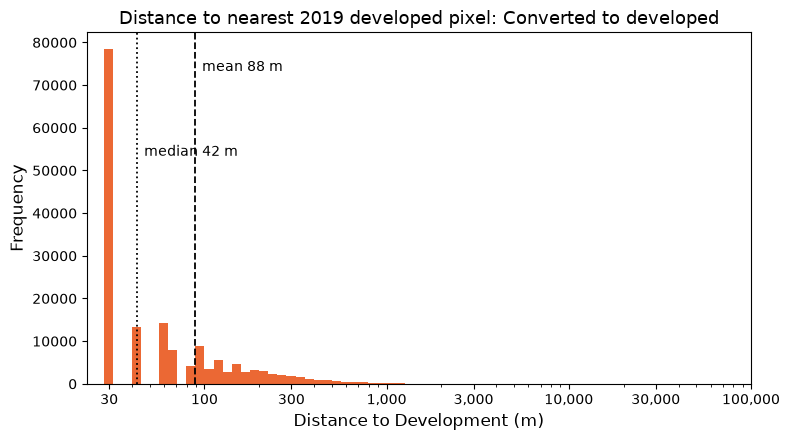

In [11]:
label_name = "Converted to developed"
grp = dist_hist[dist_hist["label_name"] == label_name].sort_values("left_m")
stats = dist_by_label.set_index("label_name").loc[label_name]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=LABEL_COLORS[label_name], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(f"Distance to nearest 2019 developed pixel: Converted to developed", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(stats["mean_dist_m"], color="black", linestyle="--", linewidth=1.3)
ax.axvline(stats["median_dist_m"], color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(stats["mean_dist_m"] * 1.1, ymax * 0.92, f"mean {stats['mean_dist_m']:,.0f} m", va="top", fontsize=10)
ax.text(stats["median_dist_m"] * 1.1, ymax * 0.68, f"median {stats['median_dist_m']:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


## Data Training

Turn the validated samples into something a model can actually train on.
Three problems need solving before any `.fit()` call is possible: the full
table doesn't fit in memory (59M rows, about 46GB dense versus 17GB here),
the classes are severely imbalanced (0.28% conversions), and neighboring
pixels are spatially correlated so a naive random split would leak. This
section builds the feature and target columns, a spatial fold split grouped
by `block_id`, and a weighted training sample that oversamples conversions
and wetland sitting close to existing development. No model gets fit here,
that's the next section. The deliverable is a persisted weighted training
pool plus an `iter_folds()` generator yielding
`(X_train, y_train, w_train, X_test, y_test)` per fold.

In [12]:
import duckdb
import numpy as np
import pandas as pd

JOINED_GLOB = "data/processed/alphaearth_wetland_joined/*.parquet"
TRAIN_POOL_PATH = "data/processed/gb_train_pool.parquet"

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW samples AS SELECT * FROM read_parquet('{JOINED_GLOB}')")

BAND_COLS = [f"A{b:02d}_{year}" for year in (2017, 2018, 2019) for b in range(64)]
DIST_COL = "dist_to_developed_2019_m"
DIST_NORM_COL = "dist_log_z"
TARGET_COL = "label_bin"
FEATURE_COLS = [DIST_NORM_COL] + BAND_COLS

### Target and features

The question we're actually asking is "does this convert to *developed*,"
not "does this change at all." So `label_bin` collapses `label == 2`
(converted to some other, not developed, class) into the negative class
right alongside `label == 0` (stayed wetland). Features are the 192
embedding bands plus `dist_to_developed_2019_m`, normalized below.

### Assigning blocks to folds

`block_id` (about 10km cells, baked in by `join_alphaearth_samples.py`'s
`add_block_id`) exists so spatially correlated neighboring pixels don't
straddle a train and test boundary. See the comment at
`join_alphaearth_samples.py`, lines 60 to 65. So the split has to happen at
the block level, not the row level, and every row of a given block has to
land in the same fold.

The assignment itself now lives in `scripts/build_train_pool.py folds`, which
writes `data/processed/block_folds.parquet`. It balances three things at once
instead of just positives: block count (a hard quota of 346/346/345/345/345),
the label=1 and label=2 counts, and total rows. The earlier version in this
notebook balanced converters alone. That got the converter counts exact but
left folds 0 and 3 holding twice the rows of the others, so test fold
prevalence swung from 0.19% to 0.43% and the per fold AP numbers were not
comparable to each other. A greedy pass gets close, then pairwise swaps
between folds close the rest of the gap: rows now agree to within about 100
out of 11.85M.

Reading it from a file rather than recomputing here also pins the assignment
across kernel restarts, which matters because the training pool is drawn
against it and would otherwise go quietly out of sync.

In [13]:
K_FOLDS = 5
BLOCK_FOLDS_PATH = "data/processed/block_folds.parquet"

block_folds = pd.read_parquet(BLOCK_FOLDS_PATH)
block_folds.groupby("fold").agg(
    blocks=("block_id", "size"), rows=("n", "sum"), n1=("n1", "sum"), n2=("n2", "sum")
)

,blocks,rows,n1,n2
fold,,,,
0,346,11853460,33181.0,44650.0
1,346,11853459,33182.0,44651.0
2,345,11853454,33181.0,44651.0
3,345,11853498,33182.0,44650.0
4,345,11853460,33182.0,44651.0


In [14]:
# block_folds is tiny (1,727 rows), so register it directly as an in memory
# table and join against the full glob instead of writing it to a file first
con.register("block_fold", block_folds[["block_id", "fold"]])
con.execute("""
    CREATE OR REPLACE VIEW samples_fold AS
    SELECT s.*, bf.fold
    FROM samples s
    JOIN block_fold bf USING (block_id)
""")

### Weighted training sample

At 0.28% positive, training on the natural distribution would leave a GBM with
almost nothing to learn the minority class from. The fix is a per row
inclusion probability, not a hard filter. Every row keeps some chance of being
drawn, so the training pool is a biased *sample* of the full population rather
than a restricted subset of it:

- `label == 1` (conversions): always included, `p = 1`, and written into the
  pool **twice**. The duplication is aimed at `min_data_in_leaf`, which counts
  rows and ignores weights, so it lets trees split more finely around
  converters.
- `label == 2` (converted to other): always included, `p = 1`, once. These
  still end up `label_bin = 0`, they just aren't thinned by sampling. They are
  the hardest negatives in the data: wetland that did change, but not into
  development.
- `label == 0`: inclusion probability decays with `dist_to_developed_2019_m`,
  `p0 = P_FLOOR + A_k * exp(-dist / TAU_M)`. `TAU_M = 200` matches the regime
  real conversions happen in (label=1 median 30 to 42m, p90 under 250m), so
  the boost concentrates on wetland sitting in the same band where conversions
  actually occur. `P_FLOOR` keeps distant wetland from ever hitting zero
  probability.

`A_k` is solved per fold in closed form so that every fold contributes the same
625,000 rows, wherever its own distance distribution happens to sit. A single
global `A` could not do that: it sized the pool as a whole, so each fold's
share came out proportional to its raw size.

Two numbers describe this pool and they disagree by roughly four times. By row
count it is about 10.6% positive. By weight, which is what LightGBM actually
optimizes since it accumulates weighted gradients and hessians, it is about
2.7%. The row figure is the misleading one.

In [15]:
TAU_M = 200.0
P_FLOOR = 0.01
POS_ROW_DUP = 2
POS_WEIGHT_MULT = 10.0
ROWS_PER_TRAINING_SET = 2_500_000
ROWS_PER_FOLD = ROWS_PER_TRAINING_SET // (K_FOLDS - 1)

# the same closed form scripts/build_train_pool.py solves, recomputed here only
# so the constants that shaped the pool are visible next to it
fold_calib = con.execute(f"""
    SELECT fold,
           SUM(CASE WHEN label = 0 THEN 1 ELSE 0 END) AS n0,
           SUM(CASE WHEN label = 1 THEN 1 ELSE 0 END) AS n1,
           SUM(CASE WHEN label = 2 THEN 1 ELSE 0 END) AS n2,
           AVG(CASE WHEN label = 0 THEN EXP(-{DIST_COL} / {TAU_M}) END) AS mean_decay
    FROM samples_fold
    GROUP BY fold
    ORDER BY fold
""").df()

fold_calib["budget0"] = ROWS_PER_FOLD - POS_ROW_DUP * fold_calib["n1"] - fold_calib["n2"]
fold_calib["A"] = (fold_calib["budget0"] / fold_calib["n0"] - P_FLOOR) / fold_calib["mean_decay"]
fold_calib

,fold,n0,n1,n2,mean_decay,budget0,A
0,0,11775629.0,33181.0,44650.0,0.196192,513988.0,0.171507
1,1,11775626.0,33182.0,44651.0,0.233058,513985.0,0.144377
2,2,11775622.0,33181.0,44651.0,0.234376,513987.0,0.143566
3,3,11775666.0,33182.0,44650.0,0.217067,513986.0,0.155013
4,4,11775627.0,33182.0,44651.0,0.195285,513985.0,0.172303


In [16]:
# the closed form above is only valid while the keep rate stays under 1. At 30m,
# the closest any wetland pixel can sit to development, it tops out near 0.17,
# so the LEAST(1.0, ...) clamp in the draw never actually bites.
fold_calib["p_at_30m"] = P_FLOOR + fold_calib["A"] * np.exp(-30 / TAU_M)
assert (fold_calib["p_at_30m"] < 1).all()

fold_calib[["fold", "mean_decay", "A", "p_at_30m"]]

,fold,mean_decay,A,p_at_30m
0,0,0.196192,0.171507,0.157618
1,1,0.233058,0.144377,0.134267
2,2,0.234376,0.143566,0.133568
3,3,0.217067,0.155013,0.143421
4,4,0.195285,0.172303,0.158303


### Load the pool

The draw runs in `scripts/build_train_pool.py pool`, which writes
`data/processed/gb_train_pool.parquet`: one pass over the full glob, keeping
rows where a hash of the pixel key falls under `p_include`. It is keyed on
`hash(row, col)` rather than `random()` because duckdb's `random()` is not
reproducible across thread counts, and both the fold assignment and the pool
need to rebuild to the same bytes.

`sample_weight` rides along. `label == 0` carries `1 / p_include`, so those
rows reconstruct the true population; `label == 2` carries 1.0, which is
already its own true count since it sat at `p = 1`; and each of the two
`label == 1` copies carries `POS_WEIGHT_MULT / POS_ROW_DUP`. That leaves the
positive boost as the single place the pool departs from reality, which is
exactly what lets the calibration step further down invert it in closed form.

The file goes stale if the fold assignment changes, or if `TAU_M`, `P_FLOOR`,
`ROWS_PER_TRAINING_SET`, `POS_ROW_DUP`, `POS_WEIGHT_MULT` or `DRAW_SEED` change
in the script. Rerun `folds` and `pool` with `--force` if any of those get
tuned. A stale pool fails loudly rather than quietly: its `fold` column would
disagree with a fresh `block_folds.parquet`, and the assertions below catch
that.

In [17]:
import os

train_pool = pd.read_parquet(TRAIN_POOL_PATH)

# a pool drawn against a superseded block_folds.parquet would still load fine
# and silently train on the wrong split, so check the parts that would differ
pool_blocks = train_pool[["block_id", "fold"]].drop_duplicates()
assert pool_blocks.merge(block_folds[["block_id", "fold"]], on=["block_id", "fold"]).shape[0] == len(pool_blocks), \
    "pool fold assignment disagrees with block_folds.parquet, rerun build_train_pool.py"
assert (train_pool.loc[train_pool["label"] == 1, "sample_weight"] == POS_WEIGHT_MULT / POS_ROW_DUP).all()

len(train_pool), train_pool[TARGET_COL].mean()

(3126041, np.float64(0.10614576072418756))

### Actual per fold training set size

`ROWS_PER_TRAINING_SET` sizes what the model sees per CV iteration, not the
pool as a whole. Each iteration trains on `train_pool[train_pool.fold != k]`,
so every fold has to contribute a fifth of it, and the per fold `A_k` above is
solved to land there. The folds now come out within about 0.3% of each other
instead of the roughly 2x spread the old global `A` left behind.

The second table is the one worth reading twice. Row share and weight share
describe the same pool and disagree by roughly four times, because the `1 / p`
weights on distant negatives run up to 100 while each converter copy carries
5. Weight share is what the loss sees.

In [18]:
pool_rows_by_fold = train_pool.groupby("fold").size().rename("pool_rows")
fold_sizes = pd.DataFrame({
    "pool_rows_held_out": pool_rows_by_fold,
    "training_rows": len(train_pool) - pool_rows_by_fold,
})
display(fold_sizes)

flagged = train_pool.assign(
    is_pos=(train_pool["label"] == 1).astype(float),
    pos_w=train_pool["sample_weight"].where(train_pool["label"] == 1, 0.0),
)
share = flagged.groupby("fold").agg(
    rows_pct=("is_pos", "mean"),
    pos_weight=("pos_w", "sum"),
    total_weight=("sample_weight", "sum"),
    mean_weight=("sample_weight", "mean"),
)
share["rows_pct"] *= 100
share["weight_pct"] = 100 * share["pos_weight"] / share["total_weight"]
share[["rows_pct", "weight_pct", "mean_weight"]]

,pool_rows_held_out,training_rows
fold,,
0,625440,2500601
1,623497,2502544
2,625159,2500882
3,626078,2499963
4,625867,2500174


,rows_pct,weight_pct,mean_weight
fold,,,
0,10.610450,2.732492,19.415335
1,10.643836,2.733559,19.468822
2,10.615219,2.732819,19.421739
3,10.599957,2.723223,19.462154
4,10.603531,2.727733,19.436525


### Fold report figures

Three things worth looking at before trusting any fold to fold comparison: how
the distance profiles differ, what the pool is actually made of, and whether the
calibrated probabilities land where they claim to.

In [19]:
import matplotlib.pyplot as plt

# Okabe Ito, chosen over the matplotlib defaults because these five series have
# to stay separable for a colorblind reader and in greyscale print
FOLD_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]
SLIDE_RC = {
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
}

# The ECDF is read straight off quantiles rather than by pulling 59M distances
# into pandas: 199 evenly spaced quantiles per fold is the same curve.
ECDF_PROBS = [i / 200 for i in range(1, 200)]
_probs_sql = "[" + ", ".join(f"{p:.5f}" for p in ECDF_PROBS) + "]"

natural_ecdf = con.execute(f"""
    SELECT fold, QUANTILE_CONT({DIST_COL}, {_probs_sql}) AS xs
    FROM samples_fold WHERE label = 0
    GROUP BY fold ORDER BY fold
""").df()

pool_ecdf = (
    train_pool[train_pool["label"] == 0]
    .groupby("fold")[DIST_COL]
    .quantile(ECDF_PROBS)
    .unstack(level=-1)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

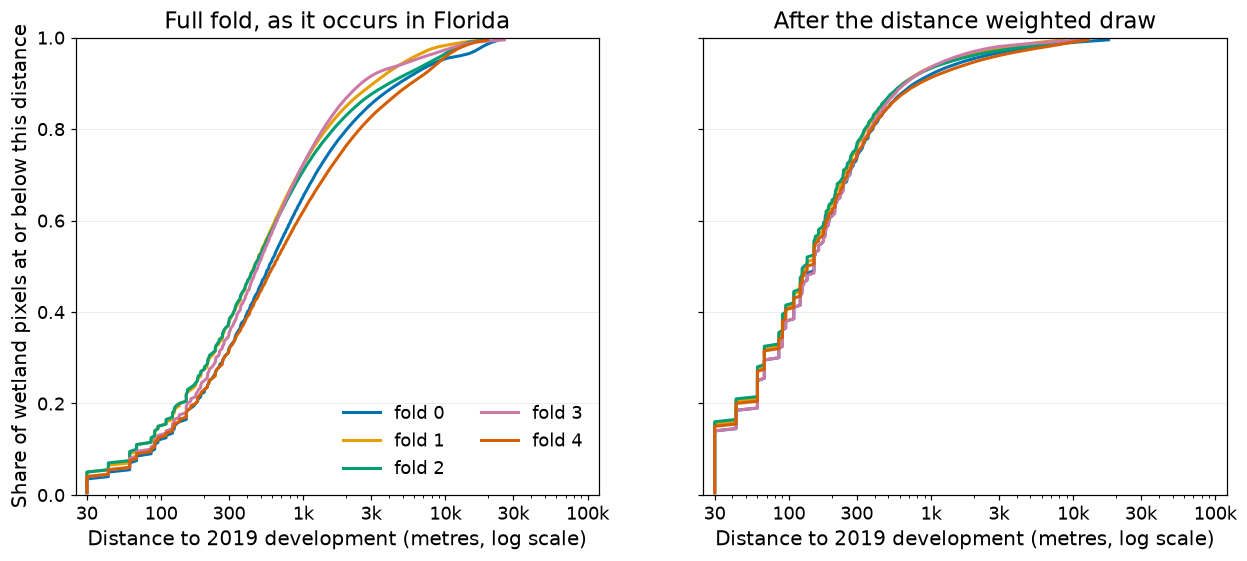

In [20]:
with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

    for k in range(K_FOLDS):
        axes[0].plot(natural_ecdf.loc[natural_ecdf["fold"] == k, "xs"].iloc[0], ECDF_PROBS,
                     color=FOLD_COLORS[k], lw=2, label=f"fold {k}")
        axes[1].plot(pool_ecdf.loc[k].to_numpy(), ECDF_PROBS,
                     color=FOLD_COLORS[k], lw=2, label=f"fold {k}")

    axes[0].set_title("Full fold, as it occurs in Florida")
    axes[1].set_title("After the distance weighted draw")
    axes[0].set_ylabel("Share of wetland pixels at or below this distance")
    for ax in axes:
        ax.set_xscale("log")
        ax.set_xlim(25, 120_000)
        ax.set_xlabel("Distance to 2019 development (metres, log scale)")
        ax.set_xticks([30, 100, 300, 1000, 3000, 10_000, 30_000, 100_000])
        ax.set_xticklabels(["30", "100", "300", "1k", "3k", "10k", "30k", "100k"])
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
    axes[0].set_ylim(0, 1)
    axes[0].legend(loc="lower right", frameon=False, ncol=2)
    plt.show()

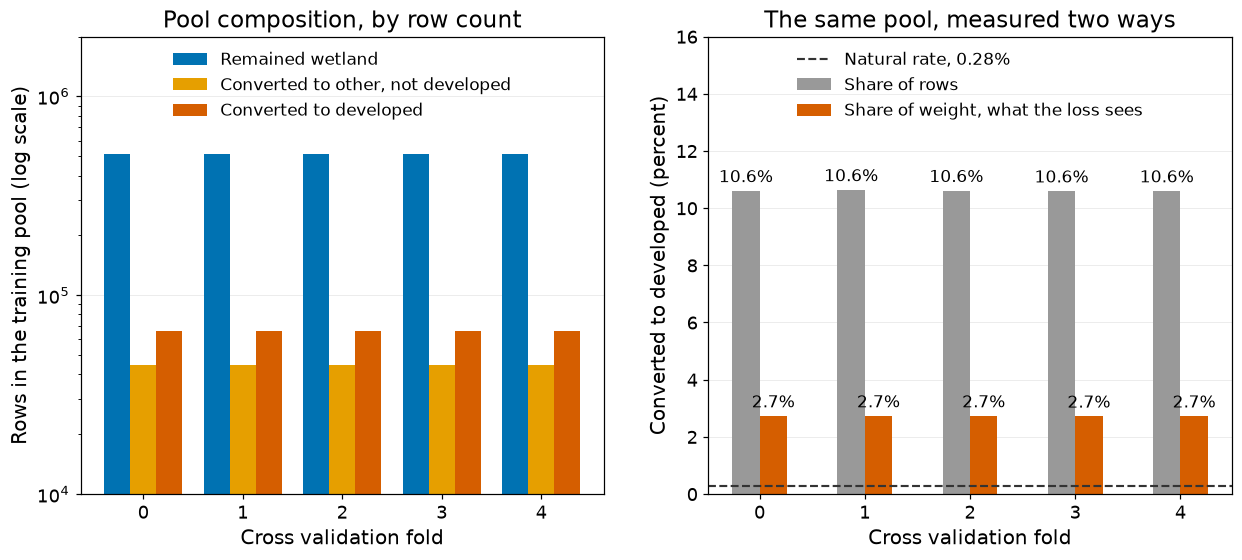

In [21]:
pool_counts = (
    train_pool.groupby(["fold", "label"]).size().unstack(fill_value=0)
    .rename(columns={0: "Remained wetland", 1: "Converted to developed",
                     2: "Converted to other, not developed"})
)
CLASS_COLORS = {"Remained wetland": "#0072B2",
                "Converted to other, not developed": "#E69F00",
                "Converted to developed": "#D55E00"}

with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

    width, folds = 0.26, np.arange(K_FOLDS)
    for i, name in enumerate(CLASS_COLORS):
        axes[0].bar(folds + (i - 1) * width, pool_counts[name], width,
                    color=CLASS_COLORS[name], label=name)
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e4, 2e6)
    axes[0].set_xticks(folds)
    axes[0].set_xlabel("Cross validation fold")
    axes[0].set_ylabel("Rows in the training pool (log scale)")
    axes[0].set_title("Pool composition, by row count")
    axes[0].legend(loc="upper center", frameon=False, fontsize=11, ncol=1)
    axes[0].grid(axis="y", alpha=0.25, lw=0.6)
    axes[0].set_axisbelow(True)

    axes[1].bar(folds - width / 2, share["rows_pct"], width, color="#999999",
                label="Share of rows")
    axes[1].bar(folds + width / 2, share["weight_pct"], width, color="#D55E00",
                label="Share of weight, what the loss sees")
    axes[1].axhline(100 * 165908 / 59267331, color="#333333", ls="--", lw=1.4,
                    label="Natural rate, 0.28%")
    for k in folds:
        axes[1].text(k - width / 2, share["rows_pct"].iloc[k] + 0.3, f"{share['rows_pct'].iloc[k]:.1f}%",
                     ha="center", fontsize=11)
        axes[1].text(k + width / 2, share["weight_pct"].iloc[k] + 0.3, f"{share['weight_pct'].iloc[k]:.1f}%",
                     ha="center", fontsize=11)
    axes[1].set_xticks(folds)
    axes[1].set_xlabel("Cross validation fold")
    axes[1].set_ylabel("Converted to developed (percent)")
    axes[1].set_ylim(0, 16)
    axes[1].set_title("The same pool, measured two ways")
    axes[1].legend(loc="upper center", frameon=False, fontsize=11)
    axes[1].grid(axis="y", alpha=0.25, lw=0.6)
    axes[1].set_axisbelow(True)
    plt.show()

### Training pool composition by fold

`Assigning blocks to folds` above balanced raw block counts and positive
counts before any sampling happened. The distance weighted draw in
`Draw and persist the pool` then thinned `label == 0` rows nonuniformly,
which could in principle throw that balance off again if one fold's
blocks happen to sit at systematically different distances from
development than another's. This checks the artifact that actually gets
trained on, `train_pool`, rather than the pre sampling block stats.

In [22]:
import matplotlib.ticker as mticker

# same 8-slot categorical order used for the label plots above, just a
# different subset of slots since this is keyed by fold id instead of label
FOLD_COLORS = {
    0: "#2a78d6",
    1: "#eb6834",
    2: "#1baf7a",
    3: "#eda100",
    4: "#e87ba4",
}
LOG_BIN_WIDTH = 0.05  # 20 bins per decade, same binning as the earlier distance-by-label plots
DIST_TICKS = [30, 100, 300, 1000, 3000, 10000, 30000, 100000]

# "Assigning blocks to folds" above balanced raw block counts and positive
# counts before any sampling happened. The distance weighted draw in "Draw
# and persist the pool" then thinned label=0 rows nonuniformly, which could
# in principle throw that balance off again if one fold's blocks happen to
# sit at systematically different distances from development than another's.
# train_pool is small (2.5M rows), so this is plain pandas, no duckdb needed.
fold_label_counts = train_pool.groupby(["fold", "label_bin"]).size().rename("n").reset_index()

bin_idx = np.floor(np.log10(train_pool["dist_to_developed_2019_m"]) / LOG_BIN_WIDTH)
fold_dist_hist = (
    pd.DataFrame({"fold": train_pool["fold"], "bin_idx": bin_idx})
    .groupby(["fold", "bin_idx"]).size().rename("n").reset_index()
)
fold_dist_hist["left_m"] = 10 ** (fold_dist_hist["bin_idx"] * LOG_BIN_WIDTH)
fold_dist_hist["right_m"] = 10 ** ((fold_dist_hist["bin_idx"] + 1) * LOG_BIN_WIDTH)


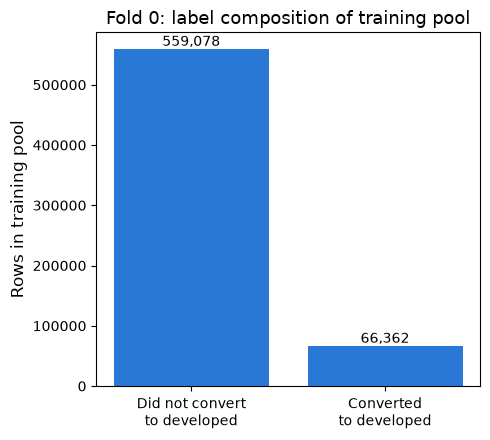

In [23]:
fold_id = 0
grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index("label_bin")["n"]
categories = ["Did not convert\nto developed", "Converted\nto developed"]
counts = [grp.get(0, 0), grp.get(1, 0)]

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(categories, counts, color=FOLD_COLORS[fold_id])
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: label composition of training pool", fontsize=13)
ax.tick_params(labelsize=10)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()


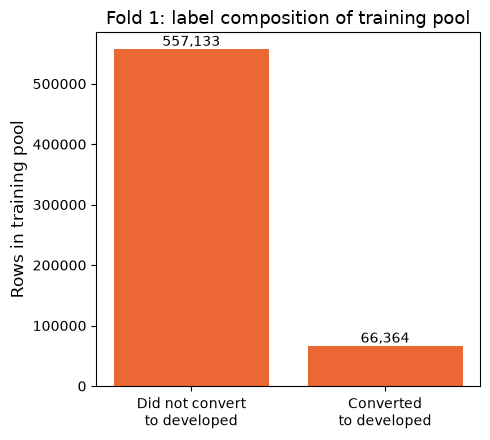

In [24]:
fold_id = 1
grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index("label_bin")["n"]
categories = ["Did not convert\nto developed", "Converted\nto developed"]
counts = [grp.get(0, 0), grp.get(1, 0)]

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(categories, counts, color=FOLD_COLORS[fold_id])
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: label composition of training pool", fontsize=13)
ax.tick_params(labelsize=10)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()


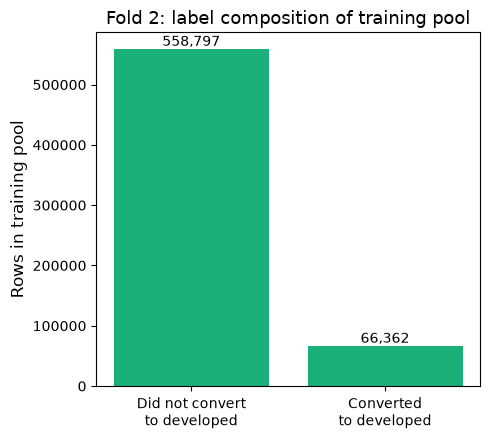

In [25]:
fold_id = 2
grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index("label_bin")["n"]
categories = ["Did not convert\nto developed", "Converted\nto developed"]
counts = [grp.get(0, 0), grp.get(1, 0)]

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(categories, counts, color=FOLD_COLORS[fold_id])
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: label composition of training pool", fontsize=13)
ax.tick_params(labelsize=10)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()


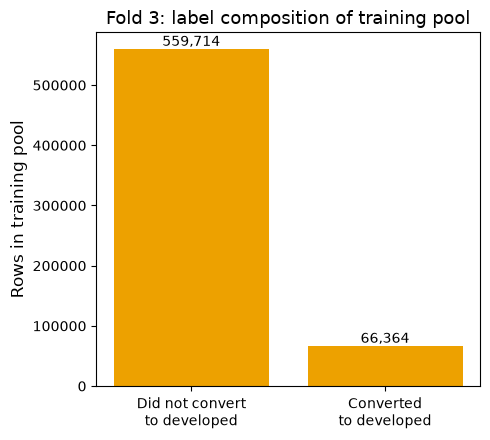

In [26]:
fold_id = 3
grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index("label_bin")["n"]
categories = ["Did not convert\nto developed", "Converted\nto developed"]
counts = [grp.get(0, 0), grp.get(1, 0)]

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(categories, counts, color=FOLD_COLORS[fold_id])
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: label composition of training pool", fontsize=13)
ax.tick_params(labelsize=10)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()


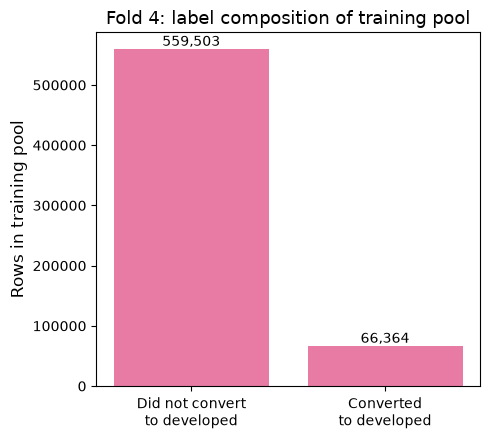

In [27]:
fold_id = 4
grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index("label_bin")["n"]
categories = ["Did not convert\nto developed", "Converted\nto developed"]
counts = [grp.get(0, 0), grp.get(1, 0)]

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(categories, counts, color=FOLD_COLORS[fold_id])
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: label composition of training pool", fontsize=13)
ax.tick_params(labelsize=10)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()


Same check for `dist_to_developed_2019_m` within each fold's pool rows:

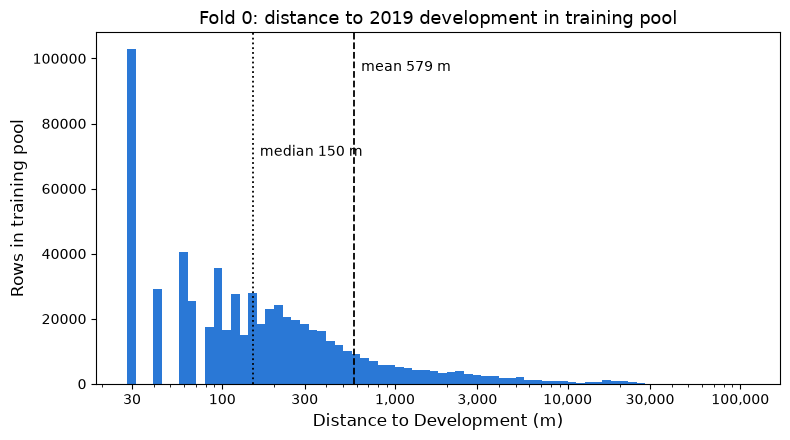

In [28]:
fold_id = 0
grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
dist_vals = train_pool.loc[train_pool["fold"] == fold_id, "dist_to_developed_2019_m"]
mean_d, median_d = dist_vals.mean(), dist_vals.median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=FOLD_COLORS[fold_id], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: distance to 2019 development in training pool", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.3)
ax.axvline(median_d, color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(mean_d * 1.1, ymax * 0.92, f"mean {mean_d:,.0f} m", va="top", fontsize=10)
ax.text(median_d * 1.1, ymax * 0.68, f"median {median_d:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


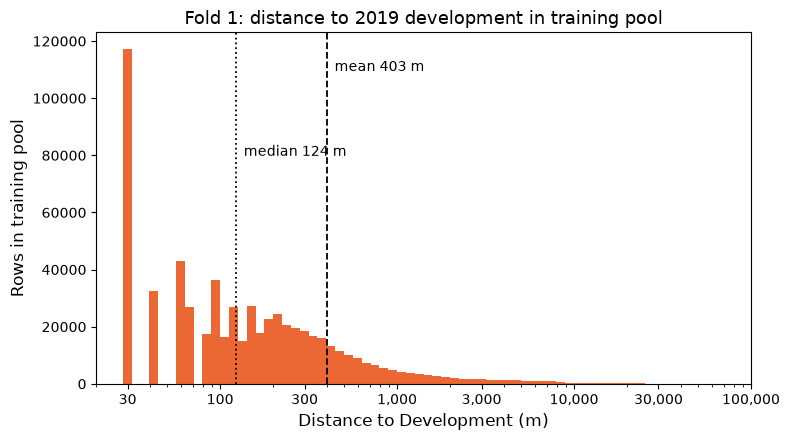

In [29]:
fold_id = 1
grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
dist_vals = train_pool.loc[train_pool["fold"] == fold_id, "dist_to_developed_2019_m"]
mean_d, median_d = dist_vals.mean(), dist_vals.median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=FOLD_COLORS[fold_id], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: distance to 2019 development in training pool", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.3)
ax.axvline(median_d, color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(mean_d * 1.1, ymax * 0.92, f"mean {mean_d:,.0f} m", va="top", fontsize=10)
ax.text(median_d * 1.1, ymax * 0.68, f"median {median_d:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


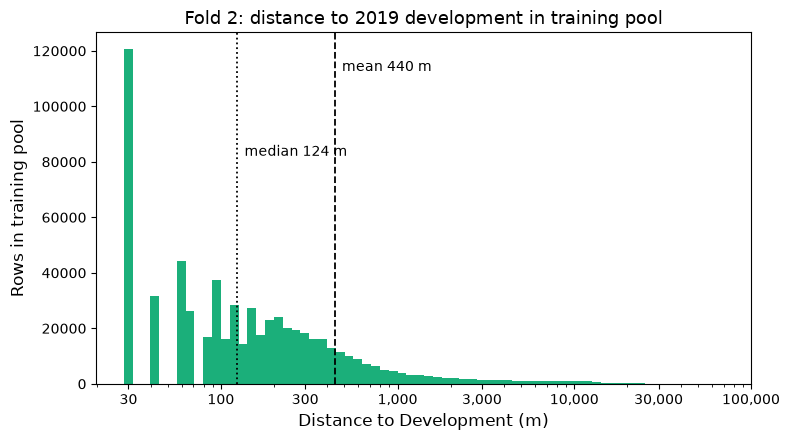

In [30]:
fold_id = 2
grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
dist_vals = train_pool.loc[train_pool["fold"] == fold_id, "dist_to_developed_2019_m"]
mean_d, median_d = dist_vals.mean(), dist_vals.median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=FOLD_COLORS[fold_id], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: distance to 2019 development in training pool", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.3)
ax.axvline(median_d, color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(mean_d * 1.1, ymax * 0.92, f"mean {mean_d:,.0f} m", va="top", fontsize=10)
ax.text(median_d * 1.1, ymax * 0.68, f"median {median_d:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


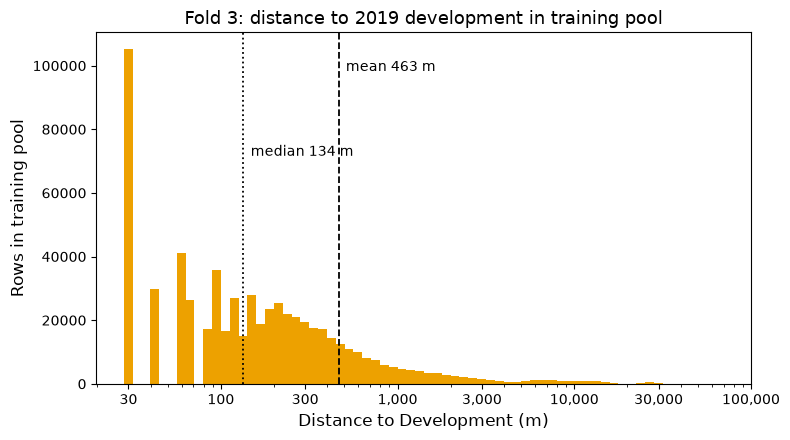

In [31]:
fold_id = 3
grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
dist_vals = train_pool.loc[train_pool["fold"] == fold_id, "dist_to_developed_2019_m"]
mean_d, median_d = dist_vals.mean(), dist_vals.median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=FOLD_COLORS[fold_id], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: distance to 2019 development in training pool", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.3)
ax.axvline(median_d, color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(mean_d * 1.1, ymax * 0.92, f"mean {mean_d:,.0f} m", va="top", fontsize=10)
ax.text(median_d * 1.1, ymax * 0.68, f"median {median_d:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


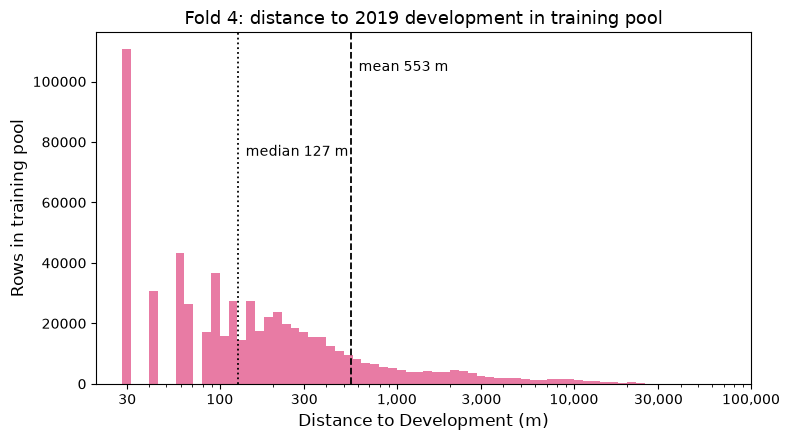

In [32]:
fold_id = 4
grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
dist_vals = train_pool.loc[train_pool["fold"] == fold_id, "dist_to_developed_2019_m"]
mean_d, median_d = dist_vals.mean(), dist_vals.median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
       align="edge", color=FOLD_COLORS[fold_id], edgecolor="none")
ax.set_xscale("log")
ax.set_xticks(DIST_TICKS)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Distance to Development (m)", fontsize=12)
ax.set_ylabel("Rows in training pool", fontsize=12)
ax.set_title(f"Fold {fold_id}: distance to 2019 development in training pool", fontsize=13)
ax.tick_params(labelsize=10)

ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.3)
ax.axvline(median_d, color="black", linestyle=":", linewidth=1.3)
ymax = ax.get_ylim()[1]
ax.text(mean_d * 1.1, ymax * 0.92, f"mean {mean_d:,.0f} m", va="top", fontsize=10)
ax.text(median_d * 1.1, ymax * 0.68, f"median {median_d:,.0f} m", va="top", fontsize=10)
fig.tight_layout()


### Per fold distance normalization

The one place leakage could sneak back in: the log1p and z score stats for
`dist_to_developed_2019_m` have to be fit only on that fold's training rows.
Fit them off `samples_fold WHERE fold != k`, the raw natural distribution,
not `train_pool`. The pool's distance profile is deliberately skewed by the
weighting above, and doesn't represent the population the model needs to
generalize to at test time.

In [33]:
def fit_dist_normalizer(fold_id: int) -> tuple[float, float]:
    stats = con.execute(f"""
        SELECT AVG(LN(1 + {DIST_COL})) AS log_mean,
               STDDEV(LN(1 + {DIST_COL})) AS log_std
        FROM samples_fold
        WHERE fold != {fold_id}
    """).df()
    return stats["log_mean"][0], stats["log_std"][0]


def add_normalized_dist(df: pd.DataFrame, log_mean: float, log_std: float) -> pd.DataFrame:
    df = df.copy()
    df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
    return df

### Held out fold, natural distribution

Test rows are pulled unweighted. The point of evaluation is an honest read on
the real 0.28% imbalance, not the boosted training distribution.

Balancing rows made every fold about 11.85M rows, which as float32 across 192
band columns is roughly 9GB. Materializing that as a pandas frame alongside the
roughly 2.4GB pool does not fit in 16GB, and the old `fold_test_frame` did
exactly that (it got away with it only because the small folds used to be
8.2M). So prediction streams instead: pull the fold in record batches, score
each batch, keep nothing but the labels and the scores. Two float arrays of
11.85M is about 95MB.

`natural_fold_sample` is the other half of the same problem. Early stopping in
the grid search needs a validation frame it can hand to LightGBM directly, and
that one does have to be materialized, so it gets a subsample instead of the
whole fold.

In [34]:
TEST_BATCH_ROWS = 200_000


def predict_fold(model, fold_id: int, log_mean: float, log_std: float,
                 feature_cols: list[str] | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Score a whole natural fold in batches. Returns (y_true, y_score)."""
    feature_cols = feature_cols or FEATURE_COLS
    reader = con.execute(f"""
        SELECT {DIST_COL}, {", ".join(BAND_COLS)},
               CASE WHEN label = 1 THEN 1 ELSE 0 END AS {TARGET_COL}
        FROM samples_fold
        WHERE fold = {fold_id}
    """).fetch_record_batch(TEST_BATCH_ROWS)

    y_true, y_score = [], []
    for batch in reader:
        df = batch.to_pandas()
        df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
        y_score.append(model.predict_proba(df[feature_cols])[:, 1])
        y_true.append(df[TARGET_COL].to_numpy())
    return np.concatenate(y_true), np.concatenate(y_score)


def natural_fold_sample(fold_id: int, n_rows: int, log_mean: float, log_std: float) -> pd.DataFrame:
    """Uniform subsample of one natural fold, for anything that needs a real frame.

    Uniform rather than stratified on purpose: early stopping should see the
    same base rate the test fold has, so thinning positives and negatives
    together is the point.
    """
    n_fold = con.execute(f"SELECT COUNT(*) FROM samples_fold WHERE fold = {fold_id}").fetchone()[0]
    frac = min(1.0, n_rows / n_fold)
    df = con.execute(f"""
        SELECT {DIST_COL}, {", ".join(BAND_COLS)},
               CASE WHEN label = 1 THEN 1 ELSE 0 END AS {TARGET_COL}
        FROM samples_fold
        WHERE fold = {fold_id}
          AND (hash("row", "col", 99) % 1073741824) / 1073741824.0 < {frac}
    """).df()
    df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
    return df

### Worked example: fold 0

Wire it together for one fold before generalizing. The sanity check at the end
matters, but read it in weight units, not row units: the weighted positive rate
on the training set should sit near 2.7%, well above the natural 0.28%, and the
test fold should come back at the natural rate since it is pulled unweighted.

Weights get rescaled to mean 1 here. `min_sum_hessian_in_leaf`, `lambda_l1` and
`lambda_l2` are all specified against unit weights, and the raw `1 / p` weights
average about 19, which would quietly weaken every one of those defaults by the
same factor. Rescaling is a pure scalar so it changes neither the optimum nor
the calibration correction.

In [35]:
FOLD_ID = 0
log_mean, log_std = fit_dist_normalizer(FOLD_ID)

train_fold = train_pool[train_pool["fold"] != FOLD_ID].pipe(add_normalized_dist, log_mean, log_std)
X_train, y_train = train_fold[FEATURE_COLS], train_fold[TARGET_COL]
w_train = train_fold["sample_weight"] / train_fold["sample_weight"].mean()

weighted_pos_rate = float((y_train * w_train).sum() / w_train.sum())
len(train_fold), train_fold[TARGET_COL].mean(), weighted_pos_rate

(2500601, np.float64(0.10615608007834916), 0.027293272334334904)

### All folds

A generator rather than a materialized list of all k folds' data. There's no
reason to pay for holding all 5 folds' train and test frames at once, when
the Model Training section is just going to loop through them one at a time
anyway.

In [36]:
def iter_folds(k: int = K_FOLDS):
    """Yield (fold_id, X_train, y_train, w_train, predict_test, make_calibrator).

    predict_test(model, feature_cols=None) streams the held out fold and hands
    back (y_true, y_score), so no caller ever holds a 9GB test frame.

    make_calibrator(model_factory, feature_cols=None) fits the isotonic on a
    nested split: an inner model trains on 3 of the 4 training folds, and the
    calibrator is fitted on its scores over the 4th. Fold k is never touched, so
    the test fold stays clean, and the outer model still trains on all 4 folds.
    """
    for fold_id in range(k):
        log_mean, log_std = fit_dist_normalizer(fold_id)
        train_fold = train_pool[train_pool["fold"] != fold_id].pipe(add_normalized_dist, log_mean, log_std)
        w_train = train_fold["sample_weight"] / train_fold["sample_weight"].mean()

        calib_fold = (fold_id + 1) % k
        inner_train = train_fold[train_fold["fold"] != calib_fold]
        calib_frame = train_fold[train_fold["fold"] == calib_fold]

        def predict_test(model, feature_cols=None, _fold=fold_id, _mean=log_mean, _std=log_std):
            return predict_fold(model, _fold, _mean, _std, feature_cols)

        def make_calibrator(model_factory, feature_cols=None, _inner=inner_train, _cal=calib_frame):
            feature_cols = feature_cols or FEATURE_COLS
            inner = model_factory()
            w_inner = _inner["sample_weight"] / _inner["sample_weight"].mean()
            inner.fit(_inner[feature_cols], _inner[TARGET_COL], sample_weight=w_inner)
            scores = inner.predict_proba(_cal[feature_cols])[:, 1]
            iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
            iso.fit(scores, _cal[TARGET_COL], sample_weight=natural_weights(_cal))
            return iso

        yield (
            fold_id,
            train_fold[FEATURE_COLS], train_fold[TARGET_COL], w_train,
            predict_test, make_calibrator,
        )

## Model Training

Fit one LightGBM classifier per fold, default hyperparameters throughout.
`random_state=0` is set only for reproducibility, not tuning. Each fold's model
trains on that fold's weighted `train_pool` split and gets scored against its
own natural, unweighted test partition, so the reported metrics reflect the
real about 0.28% base rate, not the oversampled one. Nothing here picks a best
model. This is a first read on whether the embeddings and distance feature
carry signal at all, before any tuning happens.

In [37]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    auc,
    roc_auc_score,
    roc_curve,
    accuracy_score,
)

### Choosing an operating point

`precision_recall_curve` returns one more precision and recall pair than it
does thresholds. The last pair, precision 1 and recall 0, is the curve's
closed endpoint and has no threshold behind it, so it gets dropped before
pairing precision and recall up with thresholds for the F1 search below.

The threshold this picks is chosen by looking at the same fold it gets applied
to, so the precision, recall, and F1 reported at it are a best case read, not
what a threshold picked ahead of time without seeing this data would give
you.

In [38]:
def best_f1_operating_point(precision, recall, thresholds):
    precision, recall = precision[:-1], recall[:-1]
    f1 = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    best_idx = np.argmax(f1)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1[best_idx]

### Recovering real probabilities

Two things stand between a raw LightGBM score and a real conversion probability,
and only one of them is known in advance.

The known one is the positive boost. `POS_WEIGHT_MULT` is the only place the
pool departs from the real population: the `1 / p` weights already reconstruct
label=0, and label=2 sat at `p = 1` with weight 1, so it represents exactly
itself. A pure class prior shift like that multiplies the odds by a known
constant and inverts in closed form, `p_true = p / (p + M * (1 - p))`, at no
cost in held out data.

The unknown one is the model. Measured on the held out fold's pool rows, which
are the boosted distribution and were never trained on, a default
`LGBMClassifier` returns a weighted mean prediction of 0.0208 against a weighted
actual rate of 0.0273. It under predicts by a factor of 0.76 on its own training
distribution, before any correction is applied, and the size of that miss swings
around on `n_estimators` and `learning_rate` alone. Boosted trees are not
calibrated out of the box and no amount of correct prior shift algebra fixes it.

So an isotonic regression was fitted to absorb both effects at once, on a nested
split that costs no test data: for test fold k an inner model trains on 3 of the
4 training folds and the calibrator is fitted on its scores over the 4th,
weighted by `natural_weights` so it reads out in true probability units.

**It did not help, and the loop below reports it rather than using it.** Across
the 5 folds the isotonic came out at +2.9% mean error on predicted converted
acres with a standard deviation of 21.5%, against -1.2% and 17.9% for the free
analytic correction. Two things went wrong. The isotonic is fitted on the inner
model's scores and applied to the outer model's, which are not the same
distribution, and at a 0.28% base rate its step function collapses the entire
low end to exactly zero, which is what drove fold 0 to -34%.

The deeper point is that neither method can fix the spread. A per fold error
running from -27% to +20% is the model transferring badly across Florida
geography, not a miscalibrated link function, and no calibrator fitted on the
other four folds can correct a shift specific to the held out one. Treat the
analytic correction as the point estimate and that roughly 18% spread as the
honest uncertainty on any statewide acreage figure this model produces.

In [39]:
M2_PER_ACRE = 4046.8564224
PIXEL_ACRES = 30 * 30 / M2_PER_ACRE  # 30m NLCD pixel


def calibrate(p: np.ndarray, mult: float = POS_WEIGHT_MULT) -> np.ndarray:
    """Undo the positive upweight analytically. Exact for the sampling design,
    but it cannot fix the model's own miscalibration, so it is a baseline here
    rather than the thing the metrics are read off."""
    return p / (p + mult * (1 - p))


def natural_weights(df: pd.DataFrame) -> np.ndarray:
    """Pool weights with the positive boost taken back out.

    label=0 already carries 1/p and label=2 sat at p=1, so only label=1 needs
    dividing: each of its two copies drops from POS_WEIGHT_MULT / POS_ROW_DUP to
    1 / POS_ROW_DUP, and the pair sums to the one row that actually exists.
    Weighted this way the pool reconstructs the real population, which is what
    makes an isotonic fitted on it read out in true probability units.
    """
    w = df["sample_weight"].to_numpy(dtype=float).copy()
    w[df["label"].to_numpy() == 1] /= POS_WEIGHT_MULT
    return w


def reliability(y_true: np.ndarray, p_cal: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    """Observed versus predicted conversion rate, in equal count bins of predicted risk.

    Equal count rather than equal width: at a 0.28% base rate almost every pixel
    lands in the bottom width bin, which tells you nothing.
    """
    order = np.argsort(p_cal)
    return pd.DataFrame([
        {"bin": i, "n": len(idx), "pred_mean": float(p_cal[idx].mean()), "obs_rate": float(y_true[idx].mean())}
        for i, idx in enumerate(np.array_split(order, n_bins))
    ])

### All folds

A loop instead of a function, since nothing later needs to rerun this per
fold the way `iter_folds` needed to be reusable. Curve arrays and scalar
metrics get kept for plotting and the summary table. The fold's own
`X_test`, `y_test`, and predicted probabilities do not: they get dropped
before the loop asks `iter_folds` for the next fold.

That ordering matters more than it looks. `iter_folds` builds the next
fold's test frame while the previous fold's variables are still bound to
the old names, so anything not explicitly cleared here sits in memory
alongside the next fold's frame while it's being built, right when fold 1
or 2 (about 13GB as float32) is the one coming up.

In [40]:
models = []
fold_metrics = []
roc_curves = {}
pr_curves = {}
reliability_by_fold = {}


def lgbm():
    return lgb.LGBMClassifier(random_state=0)


for fold_id, X_train, y_train, w_train, predict_test, make_calibrator in iter_folds():
    model = lgbm()
    model.fit(X_train, y_train, sample_weight=w_train)
    models.append(model)

    y_test, proba = predict_test(model)
    p_cal = calibrate(proba)                      # analytic prior shift, the one reported
    p_iso = make_calibrator(lgbm).predict(proba)  # measured for comparison, see above
    prevalence = float(y_test.mean())

    # every rank based metric is computed on the raw score. Both corrections are
    # monotone so they would give identical numbers, and the raw score is what
    # the model actually emits.
    avg_prec = average_precision_score(y_test, proba)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)

    best_threshold, best_p, best_r, best_f1 = best_f1_operating_point(precision, recall, pr_thresholds)
    accuracy = accuracy_score(y_test, proba >= best_threshold)

    pred_acres = float(p_cal.sum() * PIXEL_ACRES)
    actual_acres = float(y_test.sum() * PIXEL_ACRES)

    fold_metrics.append({
        "fold": fold_id, "avg_precision": avg_prec, "pr_auc": pr_auc,
        "accuracy": accuracy, "roc_auc": roc_auc,
        "precision": best_p, "recall": best_r, "f1": best_f1,
        # reported in calibrated units, so it can be applied to a risk map directly
        "best_threshold": float(calibrate(np.array([best_threshold]))[0]),
        "prevalence": prevalence,
        "brier": float(np.mean((p_cal - y_test) ** 2)),
        "pred_acres": pred_acres, "actual_acres": actual_acres,
        "acres_error_pct": 100 * (pred_acres / actual_acres - 1),
        "acres_error_isotonic_pct": 100 * (p_iso.sum() / y_test.sum() - 1),
    })
    roc_curves[fold_id] = (fpr, tpr)
    pr_curves[fold_id] = (recall, precision)
    reliability_by_fold[fold_id] = reliability(y_test, p_cal)

    print(f"fold {fold_id}: AP={avg_prec:.4f}  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  "
          f"acres {pred_acres:,.0f} predicted vs {actual_acres:,.0f} actual "
          f"({100 * (pred_acres / actual_acres - 1):+.1f}%)")
    del X_train, y_train, w_train, y_test, proba, p_cal, p_iso

pd.DataFrame(fold_metrics)

[LightGBM] [Info] Number of positive: 265454, number of negative: 2235147


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14115
[LightGBM] [Info] Number of data points in the train set: 2500601, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.027293 -> initscore=-3.573442
[LightGBM] [Info] Start training from score -3.573442


/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/2015937077.py:13: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Number of positive: 199090, number of negative: 1678014


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Number of positive: 199090, number of negative: 1675644


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14082
[LightGBM] [Info] Number of data points in the train set: 1874734, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.027299 -> initscore=-3.573242
[LightGBM] [Info] Start training from score -3.573242


fold 4: AP=0.0807  PR-AUC=0.0807  ROC-AUC=0.9665  acres 6,722 predicted vs 7,380 actual (-8.9%)


,fold,avg_precision,pr_auc,accuracy,roc_auc,precision,recall,f1,best_threshold,prevalence,brier,pred_acres,actual_acres,acres_error_pct,acres_error_isotonic_pct
0,0,0.105026,0.105012,0.993200,0.964041,0.138626,0.274103,0.184130,0.067688,0.002799,0.002677,5407.147147,7379.283296,-26.725307,-34.274903
1,1,0.071603,0.071594,0.992606,0.958599,0.106641,0.222470,0.144173,0.092116,0.002799,0.002850,8890.805374,7379.505691,20.479687,8.319497
2,2,0.095350,0.095337,0.993843,0.963182,0.139705,0.232573,0.174555,0.097476,0.002799,0.002719,7988.792234,7379.283296,8.259731,6.729912
3,3,0.095797,0.095784,0.993066,0.960571,0.121831,0.237930,0.161147,0.095952,0.002799,0.002711,7438.055510,7379.505691,0.793411,12.914722
4,4,0.080667,0.080656,0.994042,0.966516,0.124506,0.187059,0.149503,0.100868,0.002799,0.002755,6721.690237,7379.505691,-8.914086,20.863180


### Summary across folds

One row per fold, columns in the order that matters most first: average
precision and PR-AUC, since those are what actually matter at this base
rate, then accuracy and ROC-AUC, then the operating point chosen from the
F1 search above.

`average_precision_score` and `pr_auc` are two different computations off
the same curve: a step summed area versus a trapezoid integrated one. They
track closely but aren't the same number and shouldn't be read as
redundant. `best_threshold` isn't comparable across folds the way the
other columns are, since each fold trains its own model with its own
probability scale. It's carried along for reference, not as a value meant
to generalize past its own fold.

In [41]:
SUMMARY_COLS = ["avg_precision", "pr_auc", "accuracy", "roc_auc", "precision", "recall", "f1", "best_threshold"]
CALIB_COLS = ["brier", "pred_acres", "actual_acres", "acres_error_pct", "acres_error_isotonic_pct"]

fold_summary = pd.DataFrame(fold_metrics).set_index("fold")[SUMMARY_COLS + CALIB_COLS]
fold_summary = pd.concat([fold_summary, fold_summary.agg(["mean", "std"])])
fold_summary

,avg_precision,pr_auc,accuracy,roc_auc,precision,recall,f1,best_threshold,brier,pred_acres,actual_acres,acres_error_pct,acres_error_isotonic_pct
0,0.105026,0.105012,0.993200,0.964041,0.138626,0.274103,0.184130,0.067688,0.002677,5407.147147,7379.283296,-26.725307,-34.274903
1,0.071603,0.071594,0.992606,0.958599,0.106641,0.222470,0.144173,0.092116,0.002850,8890.805374,7379.505691,20.479687,8.319497
2,0.095350,0.095337,0.993843,0.963182,0.139705,0.232573,0.174555,0.097476,0.002719,7988.792234,7379.283296,8.259731,6.729912
3,0.095797,0.095784,0.993066,0.960571,0.121831,0.237930,0.161147,0.095952,0.002711,7438.055510,7379.505691,0.793411,12.914722
4,0.080667,0.080656,0.994042,0.966516,0.124506,0.187059,0.149503,0.100868,0.002755,6721.690237,7379.505691,-8.914086,20.863180
mean,0.089689,0.089677,0.993351,0.962582,0.126262,0.230827,0.162702,0.090820,0.002742,7289.298100,7379.416733,-1.221313,2.910482
std,0.013352,0.013350,0.000587,0.003077,0.013613,0.031272,0.016730,0.013308,0.000066,1317.281031,0.121811,17.850176,21.499898


### Reliability by fold

Equal count deciles of predicted risk, plotted against the rate actually
observed in each. Log scales on both axes, because a 0.28% base rate squashes
everything interesting into the bottom corner of a linear plot. Zero rate bins
are dropped rather than clipped, since they cannot be drawn on a log axis and
carry no calibration information.

Read the top half of the curve, not the bottom. Above roughly 1 in 10,000 the
calibrated probabilities sit close to the diagonal, and that range carries
essentially all of the predicted acreage. Below it the deciles scatter by an
order of magnitude, but a decile of 1.19M pixels predicted at 1e-5 contributes
about a dozen pixels to the statewide total, so that scatter does not move any
number anyone would quote.

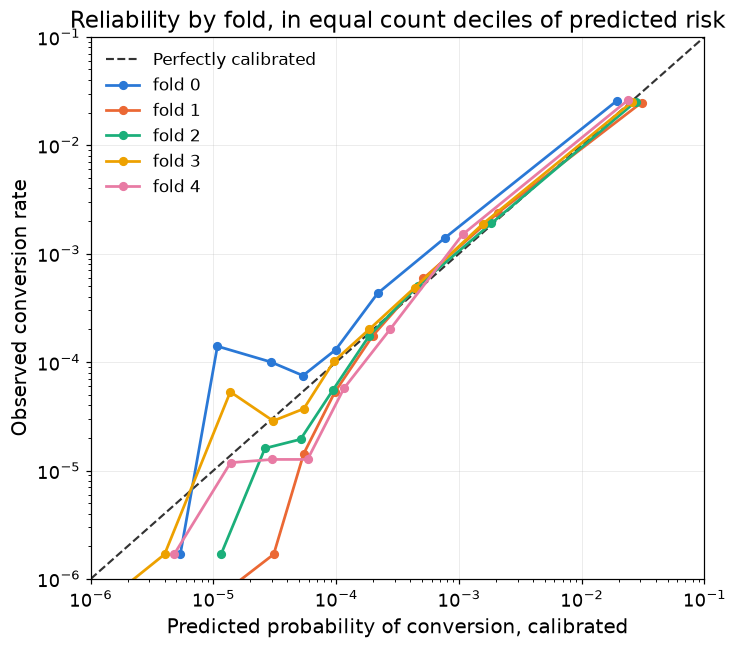

In [42]:
with plt.rc_context(SLIDE_RC):
    fig, ax = plt.subplots(figsize=(7.2, 6.4))

    lims = (1e-6, 1e-1)
    ax.plot(lims, lims, ls="--", lw=1.4, color="#333333", label="Perfectly calibrated")
    for k in range(K_FOLDS):
        rel = reliability_by_fold[k]
        keep = (rel["pred_mean"] > 0) & (rel["obs_rate"] > 0)
        ax.plot(rel.loc[keep, "pred_mean"], rel.loc[keep, "obs_rate"],
                marker="o", ms=5, lw=1.8, color=FOLD_COLORS[k], label=f"fold {k}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*lims)
    ax.set_ylim(*lims)
    ax.set_xlabel("Predicted probability of conversion, calibrated")
    ax.set_ylabel("Observed conversion rate")
    ax.set_title("Reliability by fold, in equal count deciles of predicted risk")
    ax.legend(loc="upper left", frameon=False, fontsize=11)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    plt.show()

### Export results

Save the fold summary and both plots below to
`results/models/Experiment0-AE_Distance_Features/baseline/` so this baseline
run can be referenced or compared against later without rerunning the
training loop.

In [43]:
import os

# Experiment 2 rather than overwriting Experiment 0: the folds, the pool and the
# positive boost all changed, so these numbers are not a rerun of that baseline,
# they are a different experiment against the same features.
RESULTS_DIR = "results/models/Experiment2-2XOversampling/baseline"
os.makedirs(RESULTS_DIR, exist_ok=True)
fold_summary.to_csv(f"{RESULTS_DIR}/fold_summary.csv")

### ROC by fold

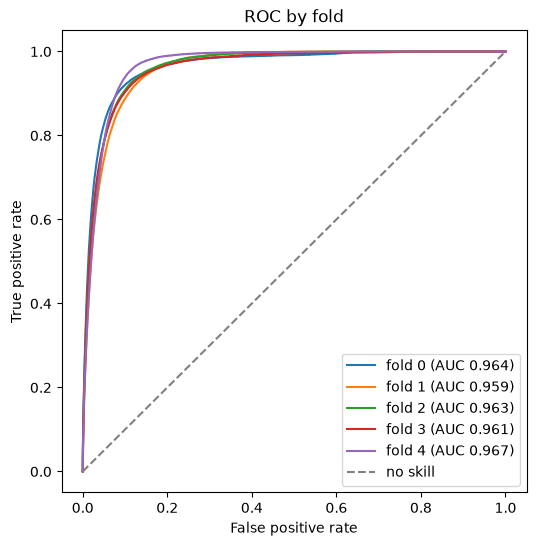

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (fpr, tpr) in roc_curves.items():
    ax.plot(fpr, tpr, label=f"fold {fold_id} (AUC {fold_summary.loc[fold_id, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="no skill")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC by fold")
ax.legend(loc="lower right")
fig.savefig(f"{RESULTS_DIR}/roc_by_fold.png", dpi=150, bbox_inches="tight")

### Precision and recall by fold

Worth remembering when reading this one: prevalence sets the no skill
baseline for a precision recall curve, and it isn't the same across folds
(about 0.19% to 0.43%, since fold assignment balanced on positive count
rather than row count, so the denominator moves fold to fold). A curve that
looks weak in isolation may still be doing real work relative to that
fold's own chance level.

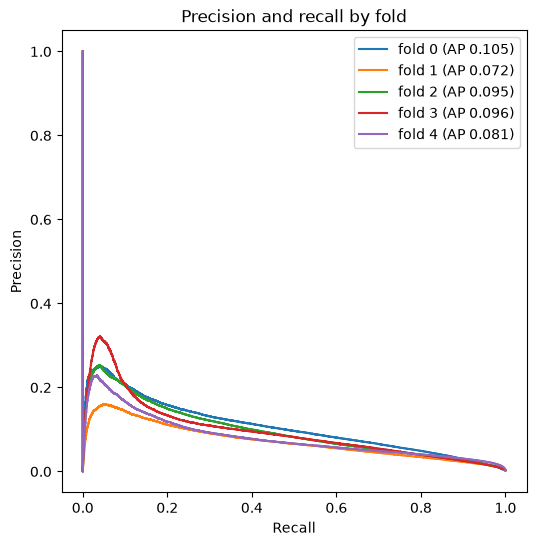

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (recall, precision) in pr_curves.items():
    ax.plot(recall, precision, label=f"fold {fold_id} (AP {fold_summary.loc[fold_id, 'avg_precision']:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision and recall by fold")
ax.legend(loc="upper right")
fig.savefig(f"{RESULTS_DIR}/pr_by_fold.png", dpi=150, bbox_inches="tight")

## Model Analysis

The baseline loop above already produced one fitted model per fold, `models[fold_id]`,
trained under Experiment 2's configuration: the rebalanced folds, the per fold pool,
the 10x positive boost. This section reuses those exact models with no retraining, to
look at a question the aggregate AP and ROC-AUC numbers can't answer on their own: is
precision and recall roughly uniform with distance to development, or is essentially
all of the model's skill concentrated in a narrow band right at the 2019 development
edge.

### Precision and recall by distance to development decile

Deciles are cut once over the full 59M row table, every label, so the bin edges are the
same real distances for every fold. That matters here specifically because precision
and recall are threshold, count based metrics, unlike AP, so a per fold decile scheme
would be comparing different real distances between folds without saying so.

Conversions are lopsided across this binning before the model ever sees them: 64% of
statewide `label == 1` pixels sit in the closest decile alone, another 20% in the
second, and by the ninth decile (1,741 to 3,937m) there are 19 converters left in 5.9M
pixels, zero beyond it. So precision and recall out there are either a very noisy small
count or fully undefined, no positives to recall at all, and undefined bins are left off
the plot rather than drawn as a misleading zero.

Each fold classifies at its own best F1 threshold, the same operating point
`fold_summary`'s precision and recall columns already report, just recovered here on
the raw score rather than the calibrated one. Calibration is a monotone rescaling, so it
changes which number labels the threshold, not which pixels end up on which side of it.

In [46]:
DIST_DECILE_EDGES = con.execute(f"""
    SELECT {", ".join(f"QUANTILE_CONT({DIST_COL}, {q / 10})" for q in range(1, 10))}
    FROM samples
""").df().iloc[0].tolist()

DIST_DECILE_LABELS = (
    [f"< {DIST_DECILE_EDGES[0]:,.0f} m"]
    + [f"{lo:,.0f}-{hi:,.0f} m" for lo, hi in zip(DIST_DECILE_EDGES[:-1], DIST_DECILE_EDGES[1:])]
    + [f"> {DIST_DECILE_EDGES[-1]:,.0f} m"]
)
DIST_DECILE_EDGES

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[67.08203887939453,
 150.0,
 241.86773681640625,
 361.2478332519531,
 510.0,
 720.0,
 1056.8348388671875,
 1741.0341796875,
 3937.321533203125]

In [47]:
def predict_fold_with_dist(model, fold_id: int, log_mean: float, log_std: float,
                           feature_cols: list[str] | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Same streamed pass as predict_fold, plus dist_to_developed_2019_m per row,
    since the decile breakdown below needs to know where each prediction sits."""
    feature_cols = feature_cols or FEATURE_COLS
    reader = con.execute(f"""
        SELECT {DIST_COL}, {", ".join(BAND_COLS)},
               CASE WHEN label = 1 THEN 1 ELSE 0 END AS {TARGET_COL}
        FROM samples_fold
        WHERE fold = {fold_id}
    """).fetch_record_batch(TEST_BATCH_ROWS)

    y_true, y_score, dist = [], [], []
    for batch in reader:
        df = batch.to_pandas()
        df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
        y_score.append(model.predict_proba(df[feature_cols])[:, 1])
        y_true.append(df[TARGET_COL].to_numpy())
        dist.append(df[DIST_COL].to_numpy())
    return np.concatenate(y_true), np.concatenate(y_score), np.concatenate(dist)

In [48]:
decile_rows = []
for fold_id in range(K_FOLDS):
    log_mean, log_std = fit_dist_normalizer(fold_id)
    y_test, proba, dist = predict_fold_with_dist(models[fold_id], fold_id, log_mean, log_std)

    # the same operating point fold_summary reports, recovered fresh here since
    # only the calibrated version of it survived past the baseline loop above
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, proba)
    best_threshold, _, _, _ = best_f1_operating_point(precision_curve, recall_curve, pr_thresholds)
    y_pred = proba >= best_threshold

    bin_idx = np.digitize(dist, DIST_DECILE_EDGES)
    for b in range(10):
        in_bin = bin_idx == b
        tp = int(np.sum(y_pred[in_bin] & (y_test[in_bin] == 1)))
        fp = int(np.sum(y_pred[in_bin] & (y_test[in_bin] == 0)))
        fn = int(np.sum(~y_pred[in_bin] & (y_test[in_bin] == 1)))
        decile_rows.append({
            "fold": fold_id, "decile": b, "label": DIST_DECILE_LABELS[b],
            "n": int(in_bin.sum()), "n_pos": tp + fn,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
            "recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        })
    del y_test, proba, dist, y_pred, bin_idx

decile_metrics = pd.DataFrame(decile_rows)
decile_metrics.pivot(index="label", columns="fold", values="n_pos").reindex(DIST_DECILE_LABELS)

/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/709809531.py:11: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/709809531.py:11: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/709809531.py:11: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


...

/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/709809531.py:11: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/var/folders/vp/b57mdvvn22lbt44d9v7qm49w0000gn/T/ipykernel_4531/709809531.py:11: DeprecationWarning: fetch_record_batch() is deprecated, use to_arrow_reader() instead.
  """).fetch_record_batch(TEST_BATCH_ROWS)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fold,0,1,2,3,4
label,,,,,
< 67 m,19709,22691,22622,20801,20302
67-150 m,6863,5987,5999,6706,7405
150-242 m,3227,2605,2581,3163,3379
242-361 m,1464,1273,1085,1359,1184
361-510 m,882,399,604,430,543
510-720 m,534,177,242,313,262
"720-1,057 m",422,47,43,235,98
"1,057-1,741 m",80,2,5,158,8
"1,741-3,937 m",0,1,0,17,1


### Figures

Both saved under `results/models/Experiment2-2XOversampling/model_analysis/`, alongside
`baseline/` and `grid_search/`. Axes are tightened to the real data range rather than
the full 0 to 1: recall never exceeds about 0.4 and precision never exceeds about 0.16
anywhere in this breakdown, so a 0 to 1 axis would flatten every fold into the bottom
corner and hide exactly the shape this figure exists to show.

In [49]:
MODEL_ANALYSIS_DIR = os.path.join(os.path.dirname(RESULTS_DIR), "model_analysis")
os.makedirs(MODEL_ANALYSIS_DIR, exist_ok=True)

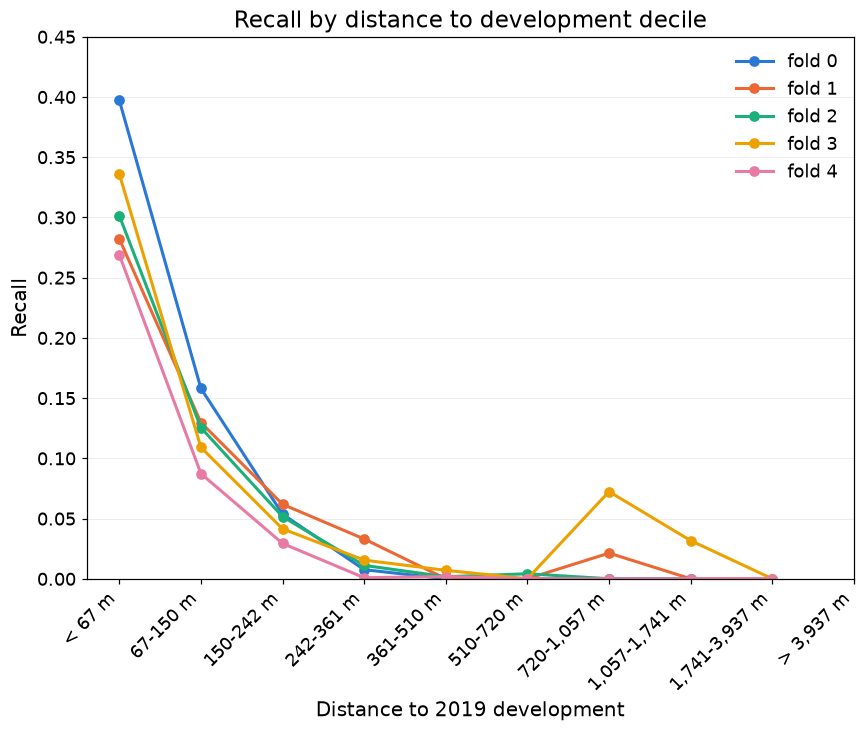

In [50]:
with plt.rc_context(SLIDE_RC):
    fig, ax = plt.subplots(figsize=(9, 6.4))

    for fold_id in range(K_FOLDS):
        d = decile_metrics[decile_metrics["fold"] == fold_id]
        ax.plot(d["decile"], d["recall"], marker="o", ms=6, lw=2,
                color=FOLD_COLORS[fold_id], label=f"fold {fold_id}")

    ax.set_xticks(range(10))
    ax.set_xticklabels(DIST_DECILE_LABELS, rotation=45, ha="right")
    ax.set_xlabel("Distance to 2019 development")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 0.45)
    ax.set_title("Recall by distance to development decile")
    ax.legend(loc="upper right", frameon=False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    fig.savefig(f"{MODEL_ANALYSIS_DIR}/recall_by_distance_decile.png")
    plt.show()

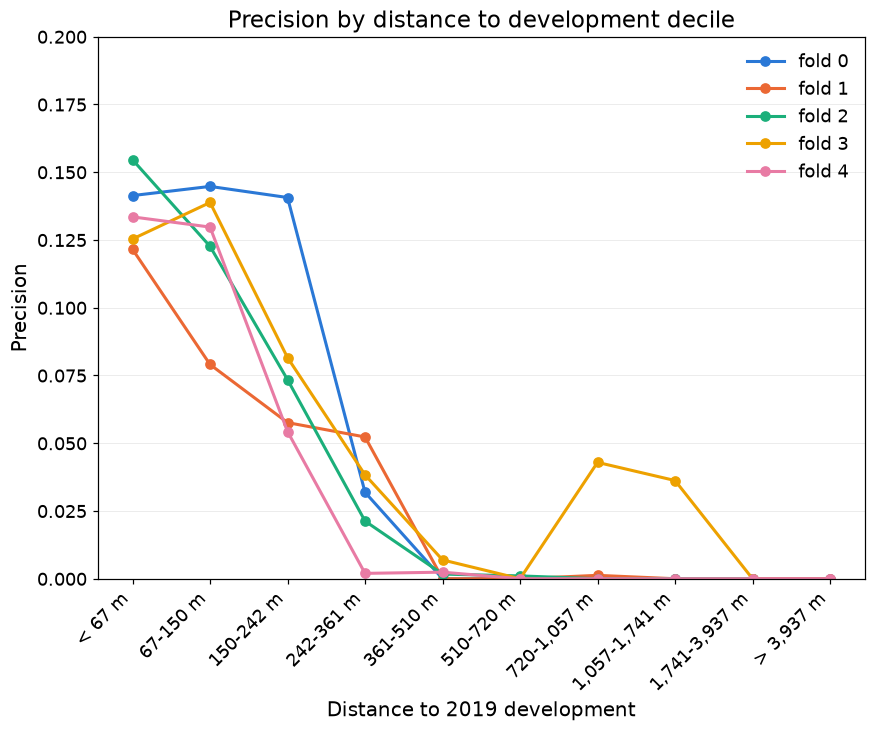

In [51]:
with plt.rc_context(SLIDE_RC):
    fig, ax = plt.subplots(figsize=(9, 6.4))

    for fold_id in range(K_FOLDS):
        d = decile_metrics[decile_metrics["fold"] == fold_id]
        ax.plot(d["decile"], d["precision"], marker="o", ms=6, lw=2,
                color=FOLD_COLORS[fold_id], label=f"fold {fold_id}")

    ax.set_xticks(range(10))
    ax.set_xticklabels(DIST_DECILE_LABELS, rotation=45, ha="right")
    ax.set_xlabel("Distance to 2019 development")
    ax.set_ylabel("Precision")
    ax.set_ylim(0, 0.20)
    ax.set_title("Precision by distance to development decile")
    ax.legend(loc="upper right", frameon=False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    fig.savefig(f"{MODEL_ANALYSIS_DIR}/precision_by_distance_decile.png")
    plt.show()

### Spatial diagnostics

The decile breakdown above answers whether skill is distance dependent. It says
nothing about where in Florida that skill actually lands, and that is the
question a reader looking at a map of their county actually has.

All three maps below come from one out of fold pass: every pixel is scored by
the model from the fold that held it out, so together the five folds cover the
whole state exactly once, with no pixel ever scored by a model that trained on
it.

Plotting 59M points is not the point of a diagnostic map, so each fold
contributes a fixed count of pixels drawn by a hash of `(row, col)`, the same
deterministic sampling `natural_fold_sample` uses for the early stopping
frame, just on its own seed so the draw is independent of that one. 100,000
pixels per fold, about 500,000 statewide, is enough to trace the coastline and
the conversion clusters without the renderer or the saved PNG choking on it.

Each fold's predicted positive uses that fold's own best F1 threshold,
recovered from `fold_summary` rather than refit here, applied to the
calibrated score.

In [52]:
MAP_SAMPLE_ROWS_PER_FOLD = 100_000  # ~500k points statewide, dense enough for a slide sized map


def sample_fold_with_xy(fold_id: int, n_rows: int, log_mean: float, log_std: float) -> pd.DataFrame:
    """Deterministic subsample of one held out fold, kept with x/y for mapping.

    Hash based on (row, col) rather than duckdb's SAMPLE, so rerunning this cell
    always draws the same pixels. Seed 21 keeps this draw independent of the
    seed 99 draw natural_fold_sample uses for the early stopping frame.
    """
    n_fold = con.execute(f"SELECT COUNT(*) FROM samples_fold WHERE fold = {fold_id}").fetchone()[0]
    frac = min(1.0, n_rows / n_fold)
    df = con.execute(f"""
        SELECT x, y, label, {DIST_COL}, {", ".join(BAND_COLS)}
        FROM samples_fold
        WHERE fold = {fold_id}
          AND (hash("row", "col", 21) % 1073741824) / 1073741824.0 < {frac}
    """).df()
    df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
    df["label_bin"] = (df["label"] == 1).astype(int)
    return df

In [53]:
map_frames = []
for fold_id in range(K_FOLDS):
    log_mean, log_std = fit_dist_normalizer(fold_id)
    df = sample_fold_with_xy(fold_id, MAP_SAMPLE_ROWS_PER_FOLD, log_mean, log_std)
    proba = models[fold_id].predict_proba(df[FEATURE_COLS])[:, 1]
    df["score"] = calibrate(proba)
    df["y_pred"] = (df["score"] >= fold_summary.loc[fold_id, "best_threshold"]).astype(int)
    map_frames.append(df[["x", "y", "label", "label_bin", "score", "y_pred"]])
    del df, proba

map_predictions = pd.concat(map_frames, ignore_index=True)
del map_frames

# tag each pixel once so the error map below doesn't recompute this per panel
map_predictions["outcome"] = np.select(
    [
        (map_predictions["label_bin"] == 1) & (map_predictions["y_pred"] == 1),
        (map_predictions["label_bin"] == 0) & (map_predictions["y_pred"] == 1),
        (map_predictions["label_bin"] == 1) & (map_predictions["y_pred"] == 0),
    ],
    ["true_positive", "false_positive", "false_negative"],
    default="true_negative",
)

len(map_predictions), map_predictions["label_bin"].mean(), map_predictions["y_pred"].mean()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(499453, np.float64(0.0028591278859071826), np.float64(0.005227719124722446))

#### Labels versus predictions

Same axes, same point styling, side by side so the eye does the comparing
instead of a legend. Gray covers everything that is not a developed
conversion, either the true label or the model's call depending on the panel;
color marks "converted to developed." If the model's orange cloud on the
right traces the same shape as the true one on the left, the skill in the
decile plot above is a real spatial pattern, not an artifact of a few lucky
folds.

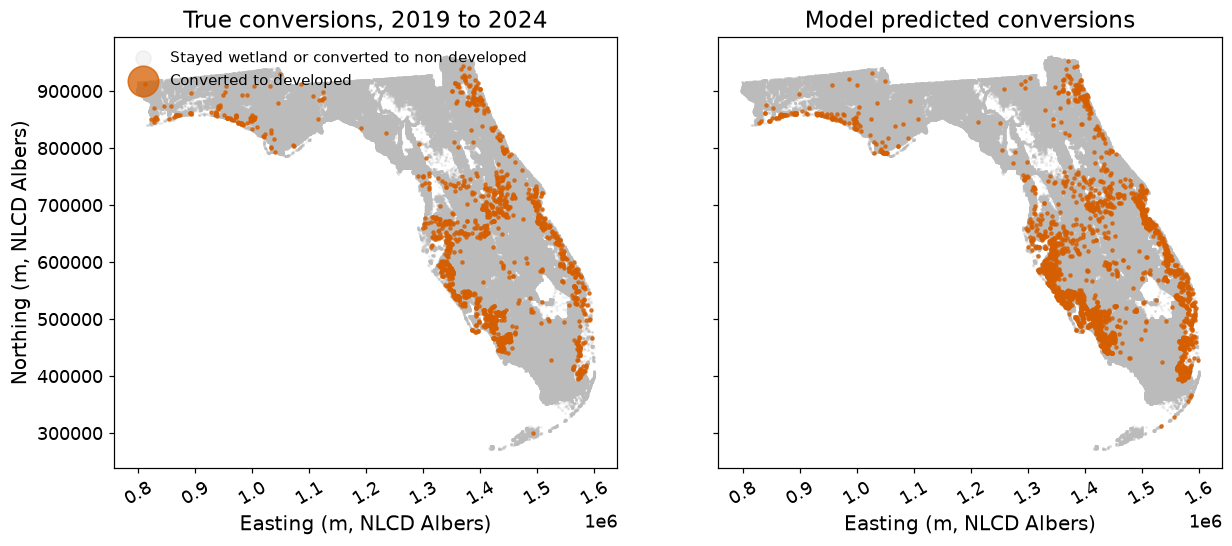

In [54]:
with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 7.2), sharex=True, sharey=True)

    panels = [("label_bin", "True conversions, 2019 to 2024"), ("y_pred", "Model predicted conversions")]
    for ax, (col, title) in zip(axes, panels):
        neg = map_predictions[map_predictions[col] == 0]
        pos = map_predictions[map_predictions[col] == 1]
        ax.scatter(neg["x"], neg["y"], s=1, alpha=0.15, color="#BBBBBB", zorder=2,
                   label="Stayed wetland or converted to non developed")
        ax.scatter(pos["x"], pos["y"], s=4, alpha=0.75, color="#D55E00", zorder=3,
                   label="Converted to developed")
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_xlabel("Easting (m, NLCD Albers)")
        ax.tick_params(axis="x", rotation=30)

    axes[0].set_ylabel("Northing (m, NLCD Albers)")
    axes[0].legend(markerscale=10, loc="upper left", frameon=False, fontsize=10)
    fig.savefig(f"{MODEL_ANALYSIS_DIR}/labels_vs_predictions_map.png")
    plt.show()

#### Errors: false positives and false negatives

A false positive is a pixel the model flags as converting that stayed
wetland; a false negative is a real conversion the model missed. Split into
separate panels because they tend to sit in different places for different
reasons, a false positive is usually the model reading a "next to
development already" signal that never actually flips within the window,
while a false negative is a conversion the embeddings gave little signal for
at all. Both panels share the same gray backdrop as above for geographic
context.

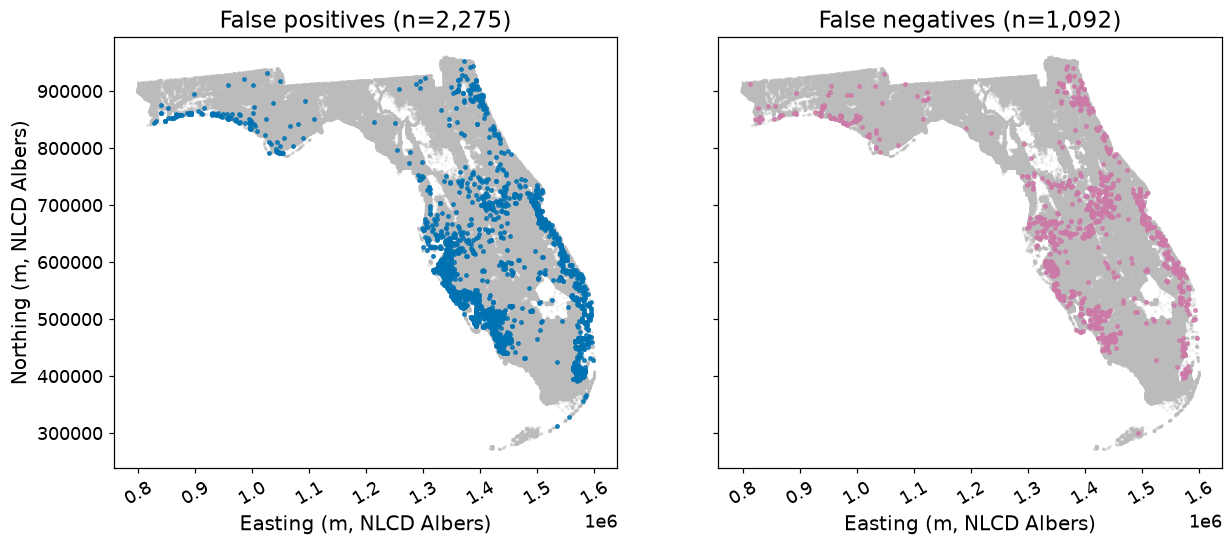

In [55]:
with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 7.2), sharex=True, sharey=True)

    background = map_predictions[map_predictions["outcome"] == "true_negative"]
    error_panels = [
        (map_predictions[map_predictions["outcome"] == "false_positive"], "#0072B2", "False positives"),
        (map_predictions[map_predictions["outcome"] == "false_negative"], "#CC79A7", "False negatives"),
    ]
    for ax, (err, color, title) in zip(axes, error_panels):
        ax.scatter(background["x"], background["y"], s=1, alpha=0.1, color="#BBBBBB", zorder=2)
        ax.scatter(err["x"], err["y"], s=5, alpha=0.8, color=color, zorder=3)
        ax.set_aspect("equal")
        ax.set_title(f"{title} (n={len(err):,})")
        ax.set_xlabel("Easting (m, NLCD Albers)")
        ax.tick_params(axis="x", rotation=30)

    axes[0].set_ylabel("Northing (m, NLCD Albers)")
    fig.savefig(f"{MODEL_ANALYSIS_DIR}/error_map.png")
    plt.show()

#### Model score across every 2019 wetland pixel

Not thresholded. The two maps above collapse a continuous score to a single
yes or no call, which hides how confident the model is anywhere short of the
operating point. Color here is the calibrated probability of conversion on a
log scale, the same reasoning as the reliability plot earlier: a 0.28% base
rate means almost every pixel's score sits under 1%, and a linear color scale
would flatten the entire state to one shade. Negatives are included, since
the point of this map is the full risk surface, not just where converters
happened to sit.

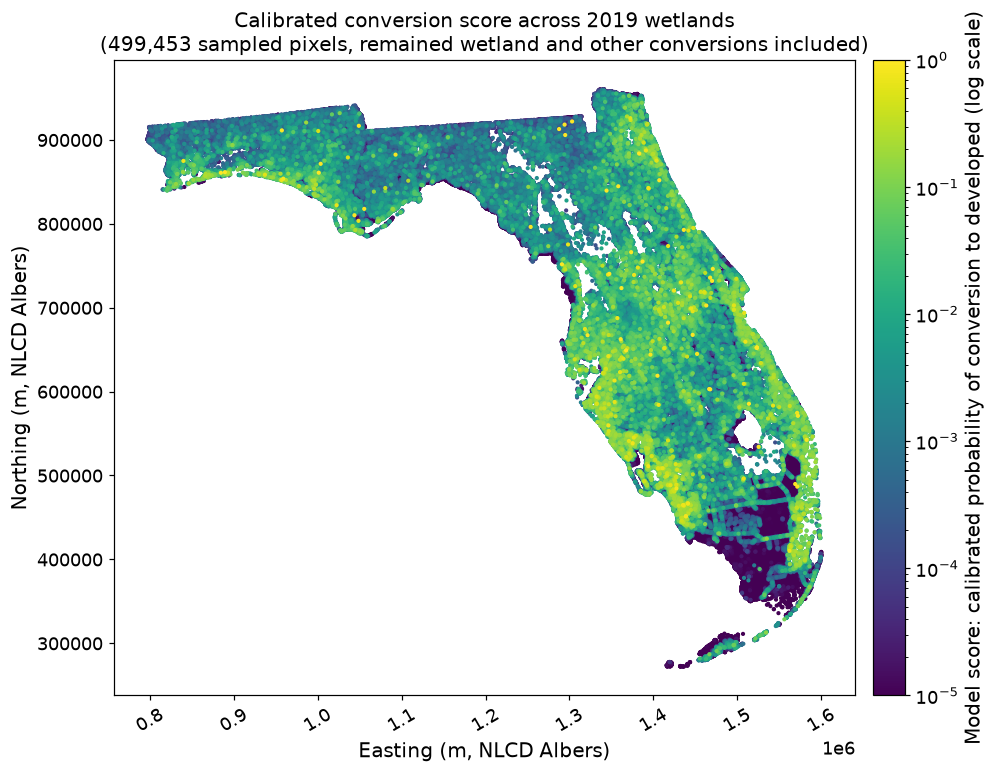

In [56]:
from matplotlib.colors import LogNorm

with plt.rc_context(SLIDE_RC):
    fig, ax = plt.subplots(figsize=(10.5, 7.5))

    plot_df = map_predictions.sort_values("score")  # lowest score first, so the hottest pixels draw on top
    vmin = max(plot_df.loc[plot_df["score"] > 0, "score"].min(), 1e-5)
    vmax = plot_df["score"].max()

    sc = ax.scatter(plot_df["x"], plot_df["y"], c=plot_df["score"].clip(lower=vmin),
                    s=3, cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax), zorder=2)
    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m, NLCD Albers)")
    ax.set_ylabel("Northing (m, NLCD Albers)")
    ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"Calibrated conversion score across 2019 wetlands\n"
                f"({len(plot_df):,} sampled pixels, remained wetland and other conversions included)",
                fontsize=13)
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Model score: calibrated probability of conversion to developed (log scale)")
    fig.savefig(f"{MODEL_ANALYSIS_DIR}/score_map.png")
    plt.show()

## Hyperparameter grid search

The baseline above is a strong ROC-AUC (about 0.95) sitting next to a weak
average precision and PR-AUC (about 0.068 and 0.069), the classic sign that
the huge negative class is flattering ROC-AUC while the metrics that
actually matter at this less than 0.3% base rate show the model isn't yet
separating rare conversions well. This screens `n_estimators`, `learning_rate`,
`num_leaves`, `feature_fraction`, and `early_stopping_rounds` against that
gap. `sample_weight` stays the inverse sampling probability throughout,
unchanged from the baseline.

A full grid across the full 5 fold CV would be far too slow (32
combinations times 5 folds), so this screens against a single fold instead:
fold 0 as the held out test, fold 1 as an early stopping validation set
pulled from the natural distribution, and the remaining folds 2 through 4
as training data. This is a screening pass to narrow the search, not a
generalization claim. It doesn't retrain the winning configuration across
all 5 folds automatically, that's worth doing separately once a promising
region of the grid is found.

### Nested split for the screening fold

Early stopping needs a validation set that isn't the training rows and isn't
the final test fold either. Scoring against the test fold while deciding how
many trees to grow would leak model selection into the number meant to be an
honest holdout. So fold 1 stands in as that validation set, pulled from the
natural, unweighted distribution the same way the test fold is, since a
decision that shapes the model should see the real base rate just like the
final metric does.

`fit_dist_normalizer` only excludes one fold and here two need excluding, so a
small variant handles that. The validation fold is subsampled to 1M rows
because LightGBM needs it as a real in memory frame for `eval_X`, while the
screening fold is only ever scored, so it streams through `predict_screen` and
costs nothing to hold.

In [ ]:
def fit_dist_normalizer_excluding(excluded_folds: list[int]) -> tuple[float, float]:
    fold_list = ", ".join(str(f) for f in excluded_folds)
    stats = con.execute(f"""
        SELECT AVG(LN(1 + {DIST_COL})) AS log_mean,
               STDDEV(LN(1 + {DIST_COL})) AS log_std
        FROM samples_fold
        WHERE fold NOT IN ({fold_list})
    """).df()
    return stats["log_mean"][0], stats["log_std"][0]


SCREEN_FOLD = 0
VAL_FOLD = (SCREEN_FOLD + 1) % K_FOLDS
TRAIN_FOLDS = [f for f in range(K_FOLDS) if f not in (SCREEN_FOLD, VAL_FOLD)]

log_mean, log_std = fit_dist_normalizer_excluding([SCREEN_FOLD, VAL_FOLD])

fit_frame = train_pool[train_pool["fold"].isin(TRAIN_FOLDS)].pipe(add_normalized_dist, log_mean, log_std)
X_fit, y_fit = fit_frame[FEATURE_COLS], fit_frame[TARGET_COL]
w_fit = fit_frame["sample_weight"] / fit_frame["sample_weight"].mean()

# Early stopping only has to rank iterations against each other, so a 1M row
# uniform subsample of the natural validation fold is plenty. Holding the full
# 11.85M row fold here, on top of the fit frame, is what would push this past
# 16GB now that the folds are evenly sized.
VAL_ROWS = 1_000_000
val_frame = natural_fold_sample(VAL_FOLD, VAL_ROWS, log_mean, log_std)
X_val, y_val = val_frame[FEATURE_COLS], val_frame[TARGET_COL]


def predict_screen(model, feature_cols=None):
    """Score the screening fold, streamed, the same way the baseline loop does."""
    return predict_fold(model, SCREEN_FOLD, log_mean, log_std, feature_cols)


(len(fit_frame), float((y_fit * w_fit).sum() / w_fit.sum()),
 len(val_frame), float(y_val.mean()))

### The grid

Two values per parameter, 32 combinations total, each tied to a specific
reason to expect it might matter here rather than a blind sweep:

- `n_estimators`: 100 (default) versus 300, tests whether the default cap is
  leaving separability on the table, with early stopping as the guard
  against overfitting the extra rounds.
- `learning_rate`: 0.1 (default) versus 0.05, the inverse probability
  weights make some rows' gradient contribution large and noisy, a smaller
  rate tests steadier updates across that weighted surface.
- `num_leaves`: 31 (default) versus 63, the 192 correlated embedding bands
  may need finer per tree splits to isolate minority signal from correlated
  background variation.
- `feature_fraction`: 1.0 (default, no subsampling) versus 0.7, a standard
  decorrelation regularizer against 192 correlated columns, a mild probe
  rather than an aggressive one.
- `early_stopping_rounds`: 10 versus 30, average precision on a validation
  fold this imbalanced is noisy round to round, tests a lean stopping rule
  against a more patient one.

In [11]:
import itertools

GRID = {
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "feature_fraction": [0.7, 1.0],
    "early_stopping_rounds": [10, 30],
}
grid_keys = list(GRID.keys())
grid_combos = list(itertools.product(*GRID.values()))
len(grid_combos)

32

### Running the grid

Each combination gets its own folder under
`results/models/Experiment0-AE_Distance_Features/grid_search/`, nested there
rather than sitting flat alongside `baseline/` so that directory doesn't get
cluttered with 32 run folders. Every folder gets a `params.txt` describing
the run, a `metrics.csv` matching `fold_summary`'s columns, and single fold
ROC and PR plots. A top level `grid_search_summary.csv` collects every run
so they're comparable without opening each folder, and gets rewritten after
every run rather than only at the end, so a crash partway through an hour
long loop doesn't lose what already finished. Each run is also wrapped so
one failed combination writes an `error.txt` and moves on instead of taking
the other 31 down with it.

`eval_metric="average_precision"` with `first_metric_only=True` on the
early stopping callback matters here specifically: LightGBM tracks
`binary_logloss` alongside whatever metric gets requested, and without
`first_metric_only` stopping would wait for both to plateau together
instead of the one this search is actually screening on. The validation
set goes in as `eval_X`/`eval_y` rather than the older `eval_set` argument,
which is deprecated on this LightGBM version and would otherwise print a
warning on every one of the 32 fits.

In [ ]:
# Experiment 2, alongside the baseline above. These runs sit on the rebalanced
# folds, the per fold pool and the 10x positive boost, so they are not
# comparable run for run against Experiment 0's grid search.
GRID_RESULTS_DIR = "results/models/Experiment2-2XOversampling/grid_search"
os.makedirs(GRID_RESULTS_DIR, exist_ok=True)
grid_summary_rows = []

for run_id, combo in enumerate(grid_combos):
    params = dict(zip(grid_keys, combo))
    run_dir = f"{GRID_RESULTS_DIR}/run_{run_id:03d}"
    os.makedirs(run_dir, exist_ok=True)

    try:
        model = lgb.LGBMClassifier(
            random_state=0, verbosity=-1,
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            feature_fraction=params["feature_fraction"],
        )
        model.fit(
            X_fit, y_fit, sample_weight=w_fit,
            eval_X=X_val, eval_y=y_val,
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(
                stopping_rounds=params["early_stopping_rounds"], first_metric_only=True, verbose=False,
            )],
        )

        y_test, proba = predict_screen(model)
        avg_prec = average_precision_score(y_test, proba)
        precision, recall, pr_thresholds = precision_recall_curve(y_test, proba)
        pr_auc = auc(recall, precision)
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)
        best_threshold, best_p, best_r, best_f1 = best_f1_operating_point(precision, recall, pr_thresholds)
        accuracy = accuracy_score(y_test, proba >= best_threshold)

        metrics = {
            "avg_precision": avg_prec, "pr_auc": pr_auc, "accuracy": accuracy, "roc_auc": roc_auc,
            "precision": best_p, "recall": best_r, "f1": best_f1,
            # calibrated, so this column means the same thing it does in fold_summary.csv
            "best_threshold": float(calibrate(np.array([best_threshold]))[0]),
        }

        with open(f"{run_dir}/params.txt", "w") as f:
            for k, v in params.items():
                f.write(f"{k}={v}\n")
            f.write("random_state=0\n")
            f.write(f"screen_fold={SCREEN_FOLD}\n")
            f.write(f"val_fold={VAL_FOLD}\n")
            f.write(f"train_folds={','.join(map(str, TRAIN_FOLDS))}\n")
            f.write(f"best_iteration={model.best_iteration_}\n")

        pd.DataFrame([metrics])[SUMMARY_COLS].to_csv(f"{run_dir}/metrics.csv", index=False)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(fpr, tpr, label=f"run {run_id:03d} (AUC {roc_auc:.3f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="no skill")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(f"ROC, run {run_id:03d}, fold {SCREEN_FOLD}")
        ax.legend(loc="lower right")
        fig.savefig(f"{run_dir}/roc.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(recall, precision, label=f"run {run_id:03d} (AP {avg_prec:.3f})")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"Precision and recall, run {run_id:03d}, fold {SCREEN_FOLD}")
        ax.legend(loc="upper right")
        fig.savefig(f"{run_dir}/pr.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

        grid_summary_rows.append({"run_id": run_id, **params, "best_iteration": model.best_iteration_, **metrics})
        print(f"run {run_id:03d}: AP={avg_prec:.3f}  PR-AUC={pr_auc:.3f}  ROC-AUC={roc_auc:.3f}  trees={model.best_iteration_}")
        del proba
    except Exception as e:
        with open(f"{run_dir}/error.txt", "w") as f:
            f.write(str(e))
        print(f"run {run_id:03d}: FAILED, {e}")
        grid_summary_rows.append({"run_id": run_id, **params, "best_iteration": None, "error": str(e)})

    pd.DataFrame(grid_summary_rows).to_csv(f"{GRID_RESULTS_DIR}/grid_search_summary.csv", index=False)

pd.DataFrame(grid_summary_rows).sort_values("avg_precision", ascending=False).head(10)

### Reading the results

`results/models/Experiment0-AE_Distance_Features/grid_search/grid_search_summary.csv`
has one row per run, params and metrics together, sorted however it's
opened, the table above is already sorted by average precision descending.
Worth remembering this screened against one fold pair, fold 0 as test and
fold 1 for early stopping, so it narrows the search rather than proving a
configuration generalizes. Whatever wins here is worth confirming with a
full 5 fold CV run before trusting it the way the baseline numbers are
trusted.

## Experiment 1: distance only

Experiment 0 trained on distance plus all 192 embedding bands and found a
real lift from tuning, but that doesn't say how much of the signal comes
from the embeddings versus `dist_to_developed_2019_m` on its own, which is
a single, well understood feature that's cheap to compute and doesn't
depend on AlphaEarth at all. This drops every embedding band and repeats
the same baseline and grid search using only distance, same spatial CV
infrastructure, same grid, so the two experiments are directly comparable.
If distance alone gets close to Experiment 0's numbers, the embeddings
aren't earning their keep. If it's far behind, that's the embeddings'
contribution made concrete.

None of `train_pool`, `iter_folds`, `predict_fold`, or the nested split built
for Experiment 0's grid search depend on which feature columns get used
downstream, only on which rows, so all of that gets reused here rather than
rebuilt. `predict_test` and `make_calibrator` both take the feature subset as
an argument, which is all this experiment needs to pass through them. The one caveat worth stating up front: `feature_fraction` in
the grid below is structurally inert with a single feature, there's nothing
to subsample, both grid values will behave identically. It's kept anyway so
this experiment's results table lines up column for column with
Experiment 0's, not because it does anything here.

In [13]:
DIST_ONLY_FEATURE_COLS = [DIST_NORM_COL]


def verify_distance_only(df: pd.DataFrame, name: str) -> pd.DataFrame:
    cols = list(df.columns)
    assert cols == DIST_ONLY_FEATURE_COLS, f"{name} has unexpected columns: {cols}"
    assert not any(c in BAND_COLS for c in cols), f"{name} leaked an AlphaEarth band column"
    return df


DIST_ONLY_FEATURE_COLS

['dist_log_z']

### Baseline

Same shape as Experiment 0's baseline loop, default hyperparameters, one
model per fold, `sample_weight` still the inverse sampling probability. The
only change is restricting `X_train`/`X_test` down to
`DIST_ONLY_FEATURE_COLS` through `verify_distance_only` before fitting.
Precision, recall, and F1 are reported at the threshold that maximizes F1
on each fold's own precision recall curve, same `best_f1_operating_point`
helper as Experiment 0, not a fixed 0.5 cutoff.

In [ ]:
models_dist = []
fold_metrics_dist = []
roc_curves_dist = {}
pr_curves_dist = {}

for fold_id, X_train_fold, y_train_fold, w_train_fold, predict_test, make_calibrator in iter_folds():
    X_train_d = verify_distance_only(X_train_fold[DIST_ONLY_FEATURE_COLS], "X_train_d")

    model = lgbm()
    model.fit(X_train_d, y_train_fold, sample_weight=w_train_fold)
    models_dist.append(model)

    y_test_fold, proba = predict_test(model, DIST_ONLY_FEATURE_COLS)
    p_cal = calibrate(proba)
    p_iso = make_calibrator(lgbm, DIST_ONLY_FEATURE_COLS).predict(proba)
    prevalence = float(y_test_fold.mean())

    avg_prec = average_precision_score(y_test_fold, proba)
    precision, recall, pr_thresholds = precision_recall_curve(y_test_fold, proba)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test_fold, proba)
    roc_auc = roc_auc_score(y_test_fold, proba)

    best_threshold, best_p, best_r, best_f1 = best_f1_operating_point(precision, recall, pr_thresholds)
    accuracy = accuracy_score(y_test_fold, proba >= best_threshold)

    pred_acres = float(p_cal.sum() * PIXEL_ACRES)
    actual_acres = float(y_test_fold.sum() * PIXEL_ACRES)

    fold_metrics_dist.append({
        "fold": fold_id, "avg_precision": avg_prec, "pr_auc": pr_auc,
        "accuracy": accuracy, "roc_auc": roc_auc,
        "precision": best_p, "recall": best_r, "f1": best_f1,
        "best_threshold": float(calibrate(np.array([best_threshold]))[0]),
        "prevalence": prevalence,
        "brier": float(np.mean((p_cal - y_test_fold) ** 2)),
        "pred_acres": pred_acres, "actual_acres": actual_acres,
        "acres_error_pct": 100 * (pred_acres / actual_acres - 1),
        "acres_error_isotonic_pct": 100 * (p_iso.sum() / y_test_fold.sum() - 1),
    })
    roc_curves_dist[fold_id] = (fpr, tpr)
    pr_curves_dist[fold_id] = (recall, precision)

    print(f"fold {fold_id}: AP={avg_prec:.4f}  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  "
          f"acres {100 * (pred_acres / actual_acres - 1):+.1f}%")
    del X_train_fold, y_train_fold, w_train_fold, X_train_d, y_test_fold, proba, p_cal, p_iso

pd.DataFrame(fold_metrics_dist)

### Summary and export

Same `SUMMARY_COLS` ordering as Experiment 0, average precision and PR-AUC
first. Saved to `results/models/Experiment1-Distance_Only/baseline/` so it
sits alongside Experiment 0's baseline for direct comparison.

In [ ]:
fold_summary_dist = pd.DataFrame(fold_metrics_dist).set_index("fold")[SUMMARY_COLS + CALIB_COLS]
fold_summary_dist = pd.concat([fold_summary_dist, fold_summary_dist.agg(["mean", "std"])])

RESULTS_DIR_DIST = "results/models/Experiment1-Distance_Only/baseline"
os.makedirs(RESULTS_DIR_DIST, exist_ok=True)
fold_summary_dist.to_csv(f"{RESULTS_DIR_DIST}/fold_summary.csv")

fold_summary_dist

### ROC and precision recall by fold, distance only

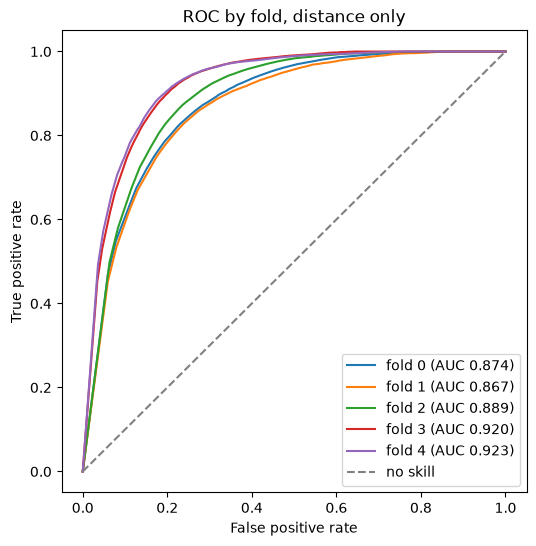

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (fpr, tpr) in roc_curves_dist.items():
    ax.plot(fpr, tpr, label=f"fold {fold_id} (AUC {fold_summary_dist.loc[fold_id, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="no skill")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC by fold, distance only")
ax.legend(loc="lower right")
fig.savefig(f"{RESULTS_DIR_DIST}/roc_by_fold.png", dpi=150, bbox_inches="tight")

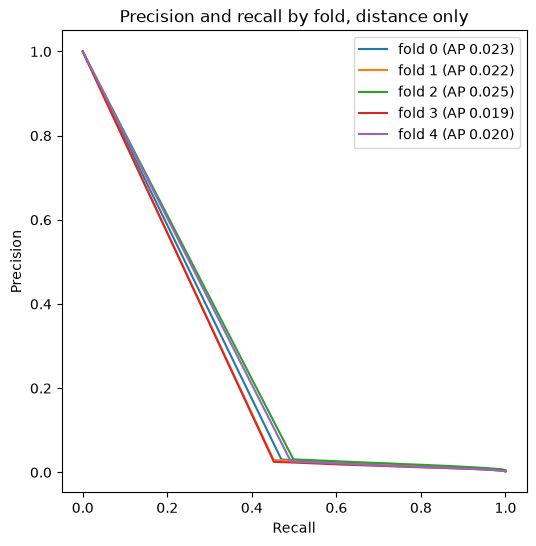

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (recall, precision) in pr_curves_dist.items():
    ax.plot(recall, precision, label=f"fold {fold_id} (AP {fold_summary_dist.loc[fold_id, 'avg_precision']:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision and recall by fold, distance only")
ax.legend(loc="upper right")
fig.savefig(f"{RESULTS_DIR_DIST}/pr_by_fold.png", dpi=150, bbox_inches="tight")

### Grid search

Reuses the fixed screen fold, validation fold, and the already computed
`X_fit`/`X_val`/`X_test` from Experiment 0's nested split setup rather than
rebuilding it, that split doesn't depend on feature columns, and reuses the
exact same `grid_combos` too, so this is genuinely the same grid, not a
retyped copy that could drift.

In [ ]:
X_fit_d = verify_distance_only(X_fit[DIST_ONLY_FEATURE_COLS], "X_fit_d")
X_val_d = verify_distance_only(X_val[DIST_ONLY_FEATURE_COLS], "X_val_d")

# no X_test_d here: the screening fold is streamed through predict_screen,
# which takes the feature subset as an argument
X_fit_d.shape, X_val_d.shape

In [ ]:
GRID_RESULTS_DIR_DIST = "results/models/Experiment1-Distance_Only/grid_search"
os.makedirs(GRID_RESULTS_DIR_DIST, exist_ok=True)
grid_summary_rows_dist = []

for run_id, combo in enumerate(grid_combos):
    params = dict(zip(grid_keys, combo))
    run_dir = f"{GRID_RESULTS_DIR_DIST}/run_{run_id:03d}"
    os.makedirs(run_dir, exist_ok=True)

    # a single feature model scores its eval set every boosting round just
    # like the 193 feature one did, so this loop is row count bound, not
    # feature count bound, and can take a while, resume by skipping any run
    # that already wrote a metrics.csv rather than redoing completed work
    metrics_path = f"{run_dir}/metrics.csv"
    if os.path.exists(metrics_path):
        row = pd.read_csv(metrics_path).iloc[0].to_dict()
        best_iteration = None
        params_path = f"{run_dir}/params.txt"
        if os.path.exists(params_path):
            for line in open(params_path):
                if line.startswith("best_iteration="):
                    best_iteration = int(line.strip().split("=")[1])
        grid_summary_rows_dist.append({"run_id": run_id, **params, "best_iteration": best_iteration, **row})
        print(f"run {run_id:03d}: already done, skipping")
        pd.DataFrame(grid_summary_rows_dist).to_csv(f"{GRID_RESULTS_DIR_DIST}/grid_search_summary.csv", index=False)
        continue

    try:
        model = lgb.LGBMClassifier(
            random_state=0, verbosity=-1,
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            feature_fraction=params["feature_fraction"],
        )
        model.fit(
            X_fit_d, y_fit, sample_weight=w_fit,
            eval_X=X_val_d, eval_y=y_val,
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(
                stopping_rounds=params["early_stopping_rounds"], first_metric_only=True, verbose=False,
            )],
        )

        y_test, proba = predict_screen(model, DIST_ONLY_FEATURE_COLS)
        avg_prec = average_precision_score(y_test, proba)
        precision, recall, pr_thresholds = precision_recall_curve(y_test, proba)
        pr_auc = auc(recall, precision)
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)
        best_threshold, best_p, best_r, best_f1 = best_f1_operating_point(precision, recall, pr_thresholds)
        accuracy = accuracy_score(y_test, proba >= best_threshold)

        metrics = {
            "avg_precision": avg_prec, "pr_auc": pr_auc, "accuracy": accuracy, "roc_auc": roc_auc,
            "precision": best_p, "recall": best_r, "f1": best_f1, "best_threshold": best_threshold,
        }

        with open(f"{run_dir}/params.txt", "w") as f:
            for k, v in params.items():
                f.write(f"{k}={v}\n")
            f.write("random_state=0\n")
            f.write(f"screen_fold={SCREEN_FOLD}\n")
            f.write(f"val_fold={VAL_FOLD}\n")
            f.write(f"train_folds={','.join(map(str, TRAIN_FOLDS))}\n")
            f.write(f"best_iteration={model.best_iteration_}\n")

        pd.DataFrame([metrics])[SUMMARY_COLS].to_csv(metrics_path, index=False)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(fpr, tpr, label=f"run {run_id:03d} (AUC {roc_auc:.3f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="no skill")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(f"ROC, run {run_id:03d}, fold {SCREEN_FOLD}, distance only")
        ax.legend(loc="lower right")
        fig.savefig(f"{run_dir}/roc.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(recall, precision, label=f"run {run_id:03d} (AP {avg_prec:.3f})")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"Precision and recall, run {run_id:03d}, fold {SCREEN_FOLD}, distance only")
        ax.legend(loc="upper right")
        fig.savefig(f"{run_dir}/pr.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

        grid_summary_rows_dist.append({"run_id": run_id, **params, "best_iteration": model.best_iteration_, **metrics})
        print(f"run {run_id:03d}: AP={avg_prec:.3f}  PR-AUC={pr_auc:.3f}  ROC-AUC={roc_auc:.3f}  trees={model.best_iteration_}")
        del proba
    except Exception as e:
        with open(f"{run_dir}/error.txt", "w") as f:
            f.write(str(e))
        print(f"run {run_id:03d}: FAILED, {e}")
        grid_summary_rows_dist.append({"run_id": run_id, **params, "best_iteration": None, "error": str(e)})

    pd.DataFrame(grid_summary_rows_dist).to_csv(f"{GRID_RESULTS_DIR_DIST}/grid_search_summary.csv", index=False)

pd.DataFrame(grid_summary_rows_dist).sort_values("avg_precision", ascending=False).head(10)

### Reading the results

`results/models/Experiment1-Distance_Only/grid_search/grid_search_summary.csv`
has the same structure as Experiment 0's, one row per run, sorted above by
average precision descending. Same caveat as before: this screened against
one fold pair, it narrows the search rather than proving a configuration
generalizes. The comparison worth making is `fold_summary_dist` against
Experiment 0's `fold_summary`, and this grid's summary against Experiment
0's, distance alone should sit meaningfully below both if the embeddings
are actually contributing signal beyond simple proximity to development.